# Machine Learning 2025/2026

### Group no. 05 - David Silva no. 53755  / Luís Reis no. 64409 / Tiago Pereira no. 55854 

# ML Project  - Learning about Donations

## Task 0 - Exploratory Data Analysis

### Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 0.1. Loading Data

In [2]:
df_donors = pd.read_csv('Donors_dataset.csv')

In [3]:
# Data Set Visualization
df_donors.head()

,TARGET_B,TARGET_D,CONTROL_NUMBER,MONTHS_SINCE_ORIGIN,DONOR_AGE,IN_HOUSE,URBANICITY,SES,CLUSTER_CODE,HOME_OWNER,...,LIFETIME_GIFT_RANGE,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LAST_GIFT_AMT,CARD_PROM_12,NUMBER_PROM_12,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_FIRST_GIFT,FILE_AVG_GIFT,FILE_CARD_GIFT
0,0,NaN,5,101,87.0,0,?,?,.,H,...,15.0,20.0,5.0,15.0,5,12,26,92,8.49,7
1,1,10.0,12,137,79.0,0,R,2,45,H,...,20.0,25.0,5.0,17.0,7,21,7,122,14.72,12
2,0,NaN,37,113,75.0,0,S,1,11,H,...,23.0,28.0,5.0,19.0,11,32,6,105,16.75,16
3,0,NaN,38,92,NaN,0,U,2,4,H,...,14.0,17.0,3.0,15.0,11,33,6,92,11.76,12
4,0,NaN,41,101,74.0,0,R,2,49,U,...,20.0,25.0,5.0,25.0,6,19,18,92,8.83,3


In [ ]:
# Data Structure Verification
print(f'df_donors')
print({df_donors.info()})

df_donors
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19372 entries, 0 to 19371
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TARGET_B                     19372 non-null  int64  
 1   TARGET_D                     4843 non-null   float64
 2   CONTROL_NUMBER               19372 non-null  int64  
 3   MONTHS_SINCE_ORIGIN          19372 non-null  int64  
 4   DONOR_AGE                    14577 non-null  float64
 5   IN_HOUSE                     19372 non-null  int64  
 6   URBANICITY                   19372 non-null  object 
 7   SES                          19372 non-null  object 
 8   CLUSTER_CODE                 19372 non-null  object 
 9   HOME_OWNER                   19372 non-null  object 
 10  DONOR_GENDER                 19372 non-null  object 
 11  INCOME_GROUP                 14980 non-null  float64
 12  PUBLISHED_PHONE              19372 non-null  int64  
 13  OVERLA

## 0.2. Understanding Data

In this task you should **understand better the features**, their distribution of values, potential errors, etc and plan/describe what data preprocessing steps should be performed next. Very important also is the distribution of values in the target (class distribution). 

Here you can find a notebook with some examples of what you can do in **Exploratory Data Analysis**: https://www.kaggle.com/artgor/exploration-of-data-step-by-step/notebook. You can also use Orange widgets for this.

In [ ]:
# Statistical Summary
print(df_donors.describe())

           TARGET_B     TARGET_D  CONTROL_NUMBER  MONTHS_SINCE_ORIGIN  \
count  19372.000000  4843.000000    19372.000000         19372.000000   
mean       0.250000    15.624344    96546.225377            73.409973   
std        0.433024    12.445137    55830.643871            41.255574   
min        0.000000     1.000000        5.000000             5.000000   
25%        0.000000    10.000000    48289.000000            29.000000   
50%        0.000000    13.000000    96937.000000            65.000000   
75%        0.250000    20.000000   145429.500000           113.000000   
max        1.000000   200.000000   191779.000000           137.000000   

          DONOR_AGE      IN_HOUSE  INCOME_GROUP  PUBLISHED_PHONE  \
count  14577.000000  19372.000000  14980.000000     19372.000000   
mean      58.919051      0.073198      3.907543         0.497729   
std       16.669382      0.260469      1.864796         0.500008   
min        0.000000      0.000000      1.000000         0.000000   
25

In [ ]:
# Missing Data Identification (Null Values Check)
missing_data = df_donors.isnull().sum()
print(missing_data[missing_data > 0])

TARGET_D                       14529
DONOR_AGE                       4795
INCOME_GROUP                    4392
WEALTH_RATING                   8810
MONTHS_SINCE_LAST_PROM_RESP      246
dtype: int64


In [5]:
# Frequency Distribution of 'URBANICITY' Column (Categorical Variable Analysis)
print(df_donors['URBANICITY'].value_counts())

URBANICITY
S    4491
C    4022
R    4005
T    3944
U    2456
?     454
Name: count, dtype: int64


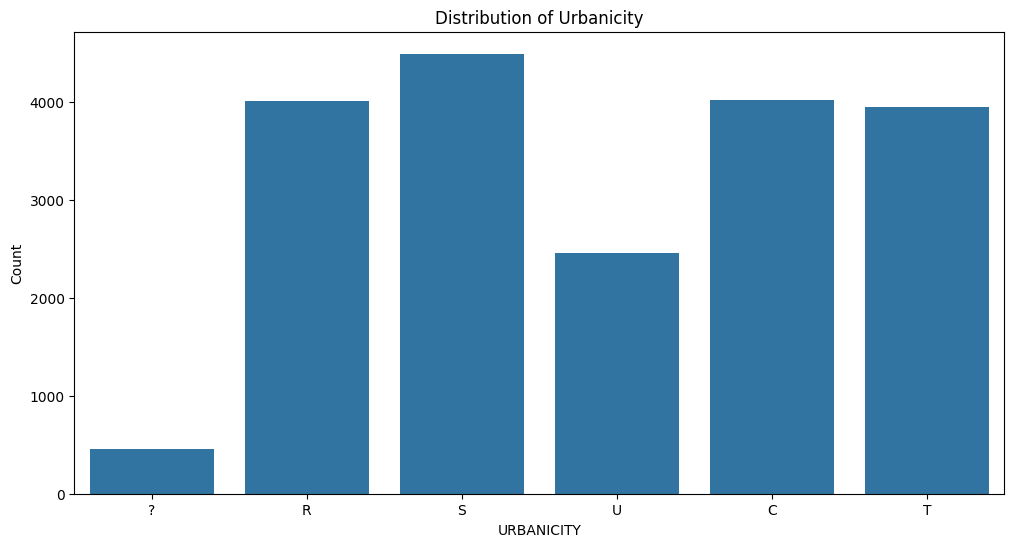

In [ ]:
# Visualization of URBANICITY Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the URBANICITY variable
sns.countplot(data=df_donors, x='URBANICITY')
# Set the title and labels
plt.title('Distribution of Urbanicity')
plt.ylabel('Count')
# Display the plot
plt.show()

In [7]:
# Frequency Distribution of 'SES' Column (Categorical Variable Analysis)
print(df_donors['SES'].value_counts())

SES
2    9284
1    5924
3    3323
?     454
4     387
Name: count, dtype: int64


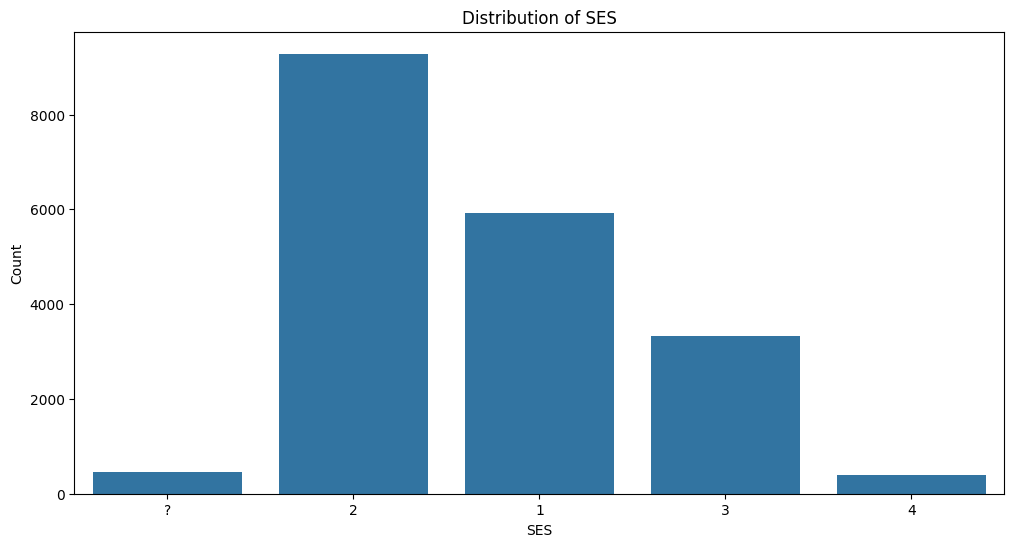

In [ ]:
# Visualization of SES Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the SES variable
sns.countplot(data=df_donors, x='SES')
# Set the title and labels
plt.title('Distribution of SES')
plt.ylabel('Count')
# Display the plot
plt.show()

In [14]:
# Frequency Distribution of 'DONOR_GENDER' Column (Categorical Variable Analysis)
print(df_donors['DONOR_GENDER'].value_counts())

DONOR_GENDER
F    10401
M     7953
U     1017
A        1
Name: count, dtype: int64


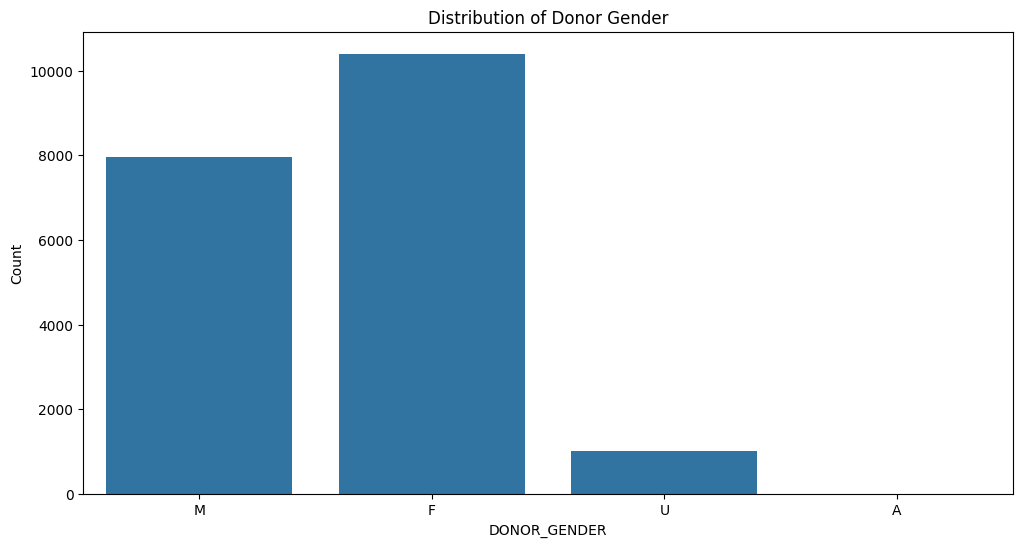

In [15]:
# Visualization of DONOR_GENDER Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the DONOR
sns.countplot(data=df_donors, x='DONOR_GENDER')
# Set the title and labels
plt.title('Distribution of Donor Gender')
plt.ylabel('Count')
# Display the plot
plt.show()

In [12]:
# Frequency Distribution of 'HOME_OWNER' Column (Categorical Variable Analysis)
print(df_donors['HOME_OWNER'].value_counts())

HOME_OWNER
H    10606
U     8766
Name: count, dtype: int64


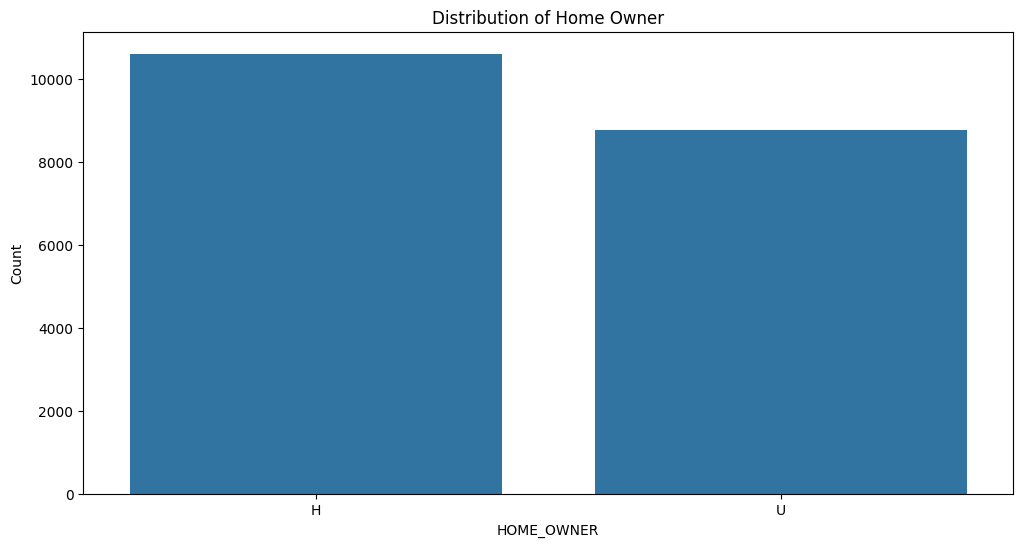

In [13]:
# Visualization of HOME_OWNER Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the HOME_OWNER variable
sns.countplot(data=df_donors, x='HOME_OWNER')
# Set the title and labels
plt.title('Distribution of Home Owner')
plt.ylabel('Count')
# Display the plot
plt.show()

In [16]:
# Frequency Distribution of 'OVERLAY_SOURCE' Column (Categorical Variable Analysis)
print(df_donors['OVERLAY_SOURCE'].value_counts())

OVERLAY_SOURCE
B    8732
P    4768
N    4392
M    1480
Name: count, dtype: int64


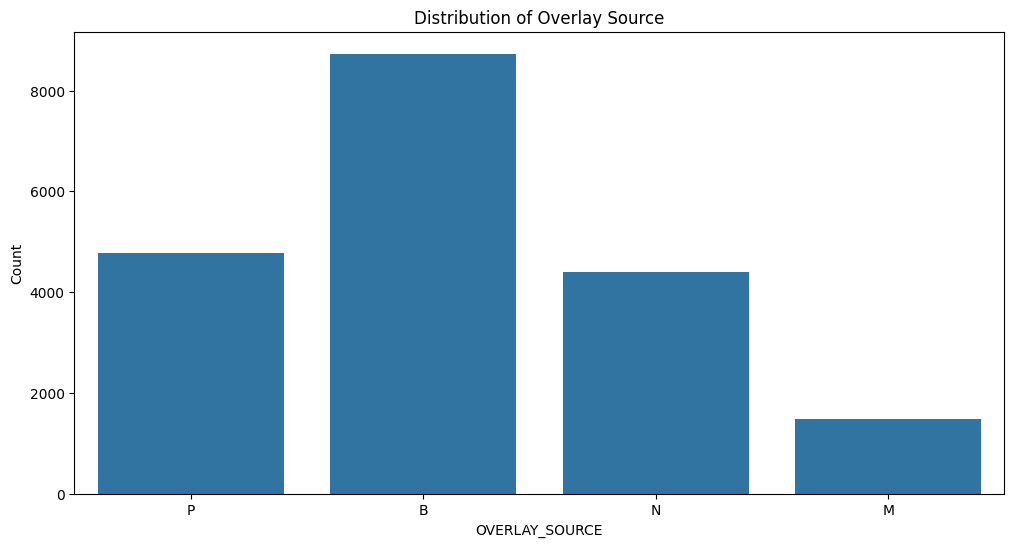

In [17]:
# Visualization of OVERLAY_SOURCE Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the OVERLAY_SOURCE variable
sns.countplot(data=df_donors, x='OVERLAY_SOURCE')
# Set the title and labels
plt.title('Distribution of Overlay Source')
plt.ylabel('Count')
# Display the plot
plt.show()

In [10]:
# Frequency Distribution of 'CLUSTER_CODE' Column (Categorical Variable Analysis)
print(df_donors['CLUSTER_CODE'].value_counts())

CLUSTER_CODE
40    830
24    795
35    727
36    716
49    675
27    666
12    631
18    619
13    579
30    519
39    512
11    484
45    482
43    468
51    460
.     454
14    454
41    431
10    387
16    384
44    383
2     380
8     378
46    369
21    353
17    349
28    343
20    317
53    303
3     300
23    293
34    284
42    284
25    273
22    251
31    249
38    240
1     239
15    223
37    204
26    202
5     199
47    185
7     184
48    180
29    170
50    156
9     153
32    152
6     123
4     113
33    109
19     98
52     60
Name: count, dtype: int64


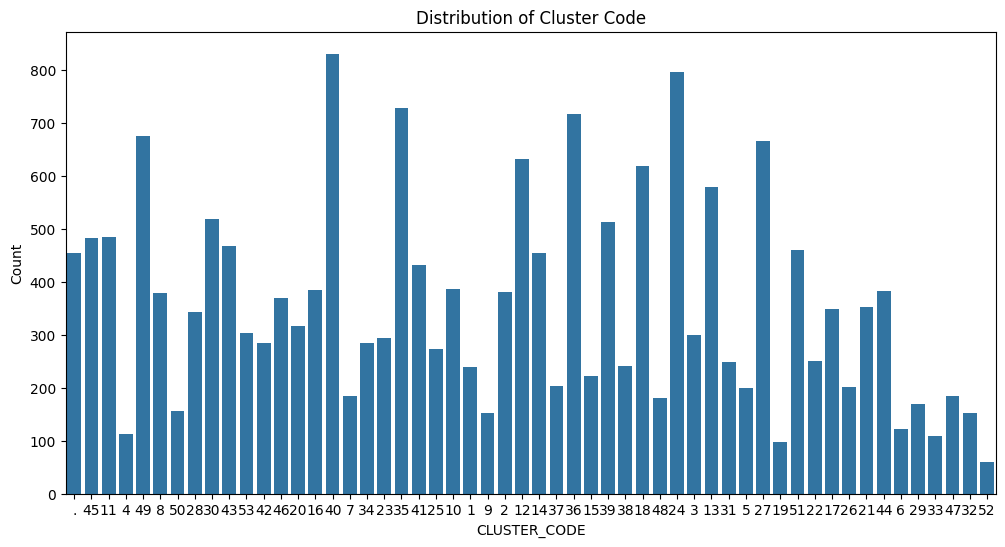

In [11]:
# Visualization of CLUSTER_CODE Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the CLUSTER_CODE variable
sns.countplot(data=df_donors, x='CLUSTER_CODE')
# Set the title and labels
plt.title('Distribution of Cluster Code')
plt.ylabel('Count')
# Display the plot
plt.show()

In [18]:
# Frequency Distribution of 'RECENCY_STATUS_96NK' Column (Categorical Variable Analysis)
print(df_donors['RECENCY_STATUS_96NK'].value_counts())

RECENCY_STATUS_96NK
A    11918
S     4221
F     1521
N     1192
E      427
L       93
Name: count, dtype: int64


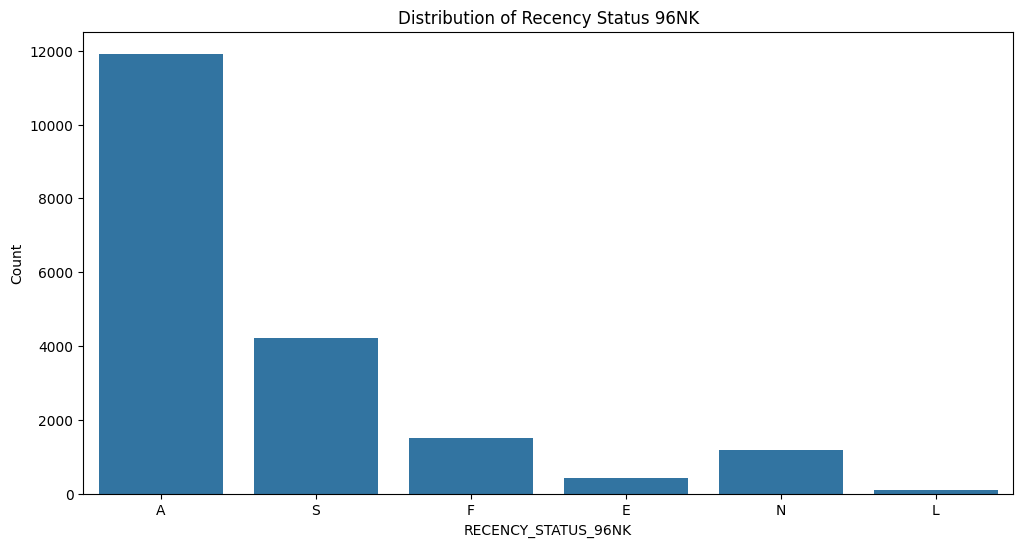

In [19]:
# Visualization of RECENCY_STATUS_96NK Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the RECENCY_STATUS_96NK variable
sns.countplot(data=df_donors, x='RECENCY_STATUS_96NK')
# Set the title and labels
plt.title('Distribution of Recency Status 96NK')
plt.ylabel('Count')
# Display the plot
plt.show()

In [ ]:
# Frequency Distribution of 'FREQUENCY_STATUS_97NK' Column (Categorical Variable Analysis)
print(df_donors['FREQUENCY_STATUS_97NK'].value_counts())

FREQUENCY_STATUS_97NK
1    9118
2    4191
3    3318
4    2745
Name: count, dtype: int64


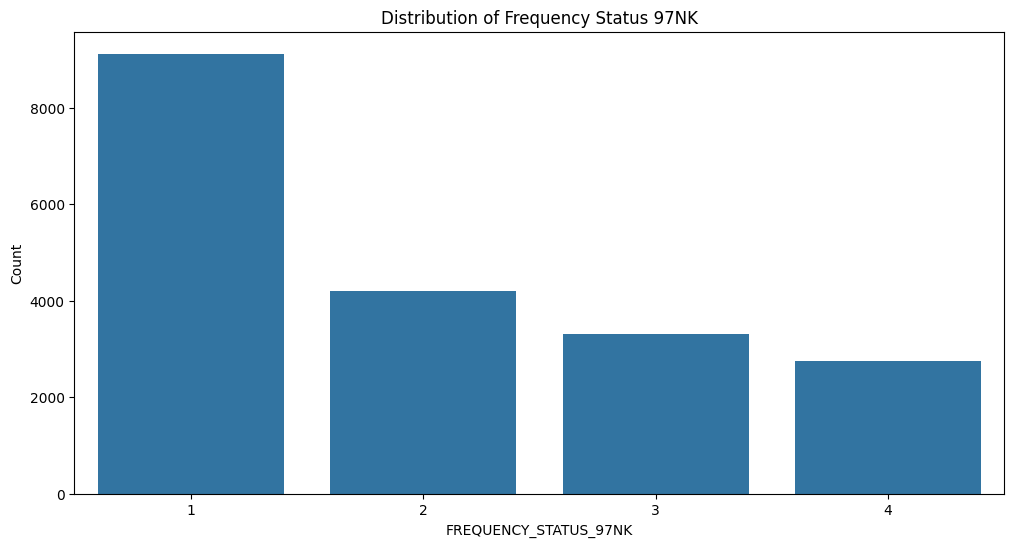

In [ ]:
# Visualization of FREQUENCY_STATUS_97NK Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the FREQUENCY_STATUS_97NK variable
sns.countplot(data=df_donors, x='FREQUENCY_STATUS_97NK')
# Set the title and labels
plt.title('Distribution of Frequency Status 97NK')
plt.ylabel('Count')
# Display the plot
plt.show()

In [ ]:
# Numerical Variable Analysis
# Filtering the numerical variables
numerical_columns = df_donors.select_dtypes(include=['float64', 'int64']).columns

# Displaying the numerical variables
print("Numerical Variables:")
for column in numerical_columns:
    print(column)

Numerical Variables:
TARGET_B
TARGET_D
CONTROL_NUMBER
MONTHS_SINCE_ORIGIN
DONOR_AGE
IN_HOUSE
INCOME_GROUP
PUBLISHED_PHONE
MOR_HIT_RATE
WEALTH_RATING
MEDIAN_HOME_VALUE
MEDIAN_HOUSEHOLD_INCOME
PCT_OWNER_OCCUPIED
PER_CAPITA_INCOME
PCT_ATTRIBUTE1
PCT_ATTRIBUTE2
PCT_ATTRIBUTE3
PCT_ATTRIBUTE4
PEP_STAR
RECENT_STAR_STATUS
FREQUENCY_STATUS_97NK
RECENT_RESPONSE_PROP
RECENT_AVG_GIFT_AMT
RECENT_CARD_RESPONSE_PROP
RECENT_AVG_CARD_GIFT_AMT
RECENT_RESPONSE_COUNT
RECENT_CARD_RESPONSE_COUNT
MONTHS_SINCE_LAST_PROM_RESP
LIFETIME_CARD_PROM
LIFETIME_PROM
LIFETIME_GIFT_AMOUNT
LIFETIME_GIFT_COUNT
LIFETIME_AVG_GIFT_AMT
LIFETIME_GIFT_RANGE
LIFETIME_MAX_GIFT_AMT
LIFETIME_MIN_GIFT_AMT
LAST_GIFT_AMT
CARD_PROM_12
NUMBER_PROM_12
MONTHS_SINCE_LAST_GIFT
MONTHS_SINCE_FIRST_GIFT
FILE_AVG_GIFT
FILE_CARD_GIFT


Summary Statistics for TARGET_B:
count    19372.000000
mean         0.250000
std          0.433024
min          0.000000
25%          0.000000
50%          0.000000
75%          0.250000
max          1.000000
Name: TARGET_B, dtype: float64


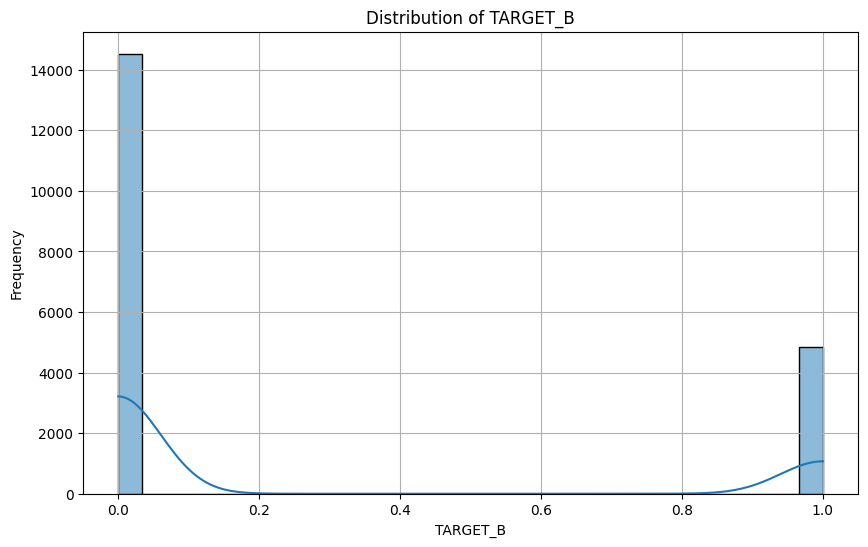

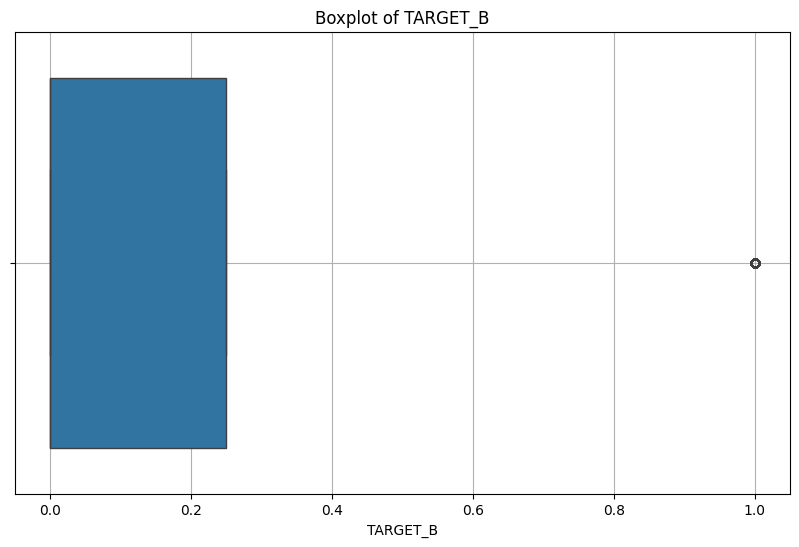

Number of Outliers in TARGET_B: 4843
Summary Statistics for TARGET_D:
count    4843.000000
mean       15.624344
std        12.445137
min         1.000000
25%        10.000000
50%        13.000000
75%        20.000000
max       200.000000
Name: TARGET_D, dtype: float64


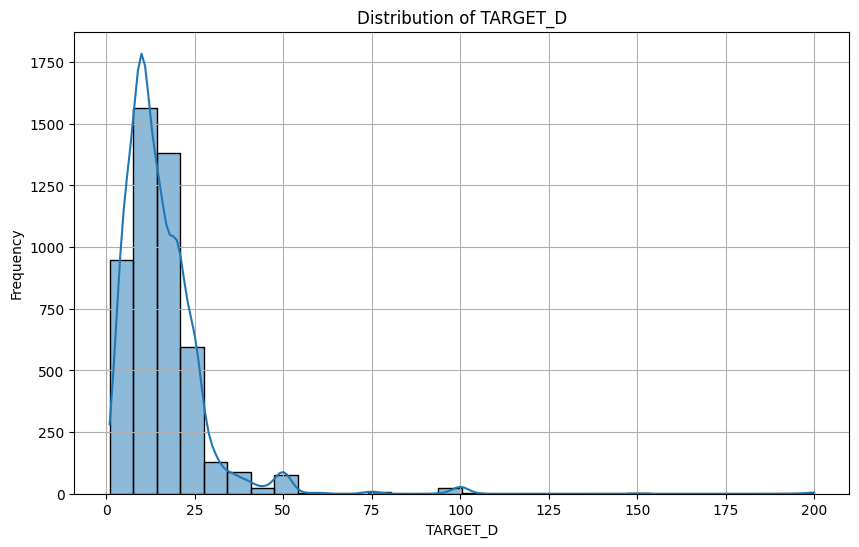

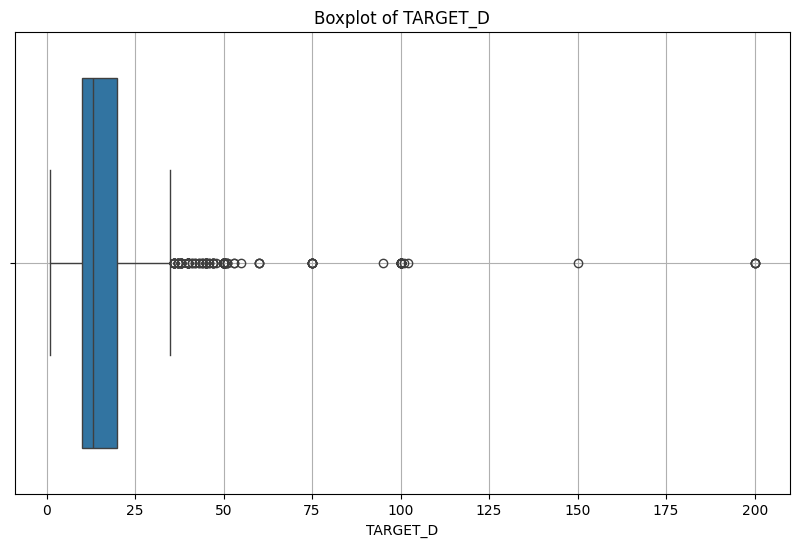

Number of Outliers in TARGET_D: 189
Summary Statistics for CONTROL_NUMBER:
count     19372.000000
mean      96546.225377
std       55830.643871
min           5.000000
25%       48289.000000
50%       96937.000000
75%      145429.500000
max      191779.000000
Name: CONTROL_NUMBER, dtype: float64


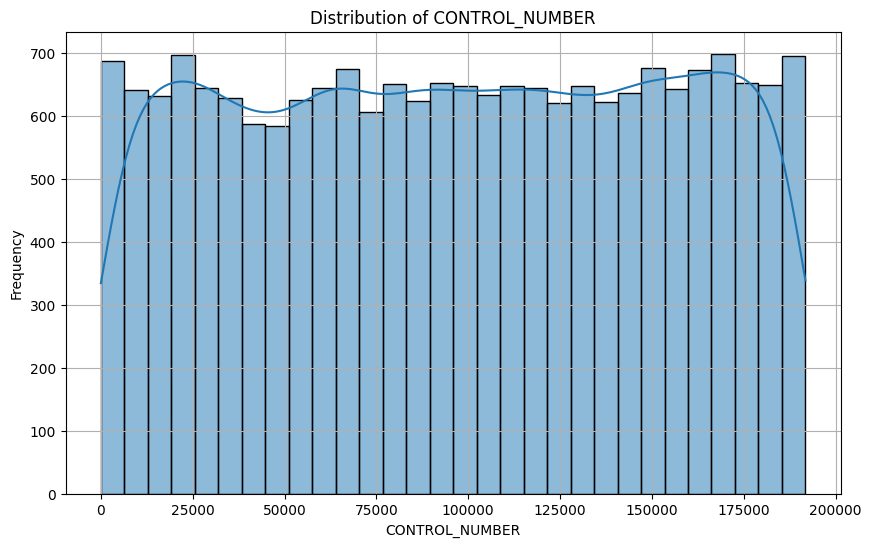

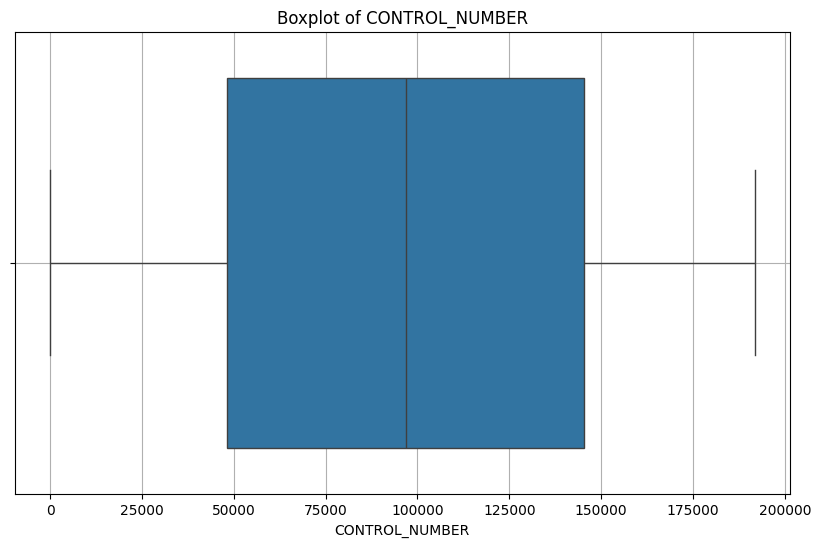

Number of Outliers in CONTROL_NUMBER: 0
Summary Statistics for MONTHS_SINCE_ORIGIN:
count    19372.000000
mean        73.409973
std         41.255574
min          5.000000
25%         29.000000
50%         65.000000
75%        113.000000
max        137.000000
Name: MONTHS_SINCE_ORIGIN, dtype: float64


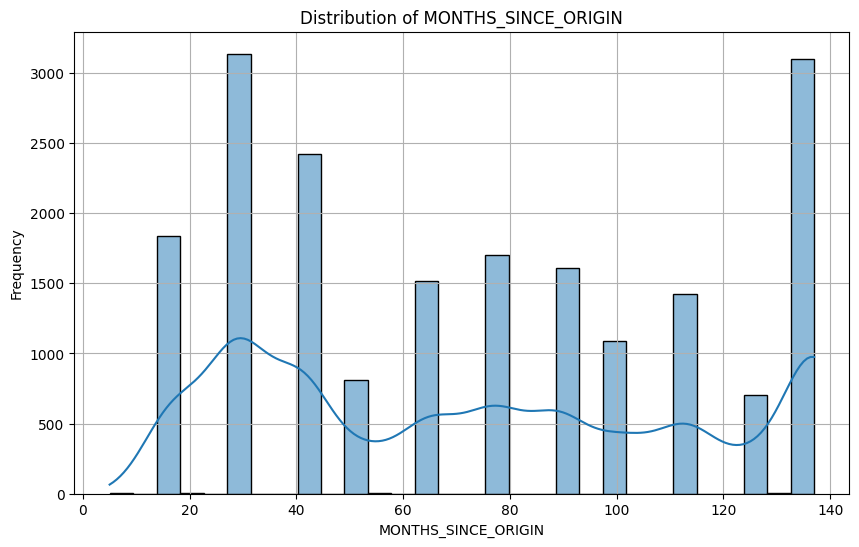

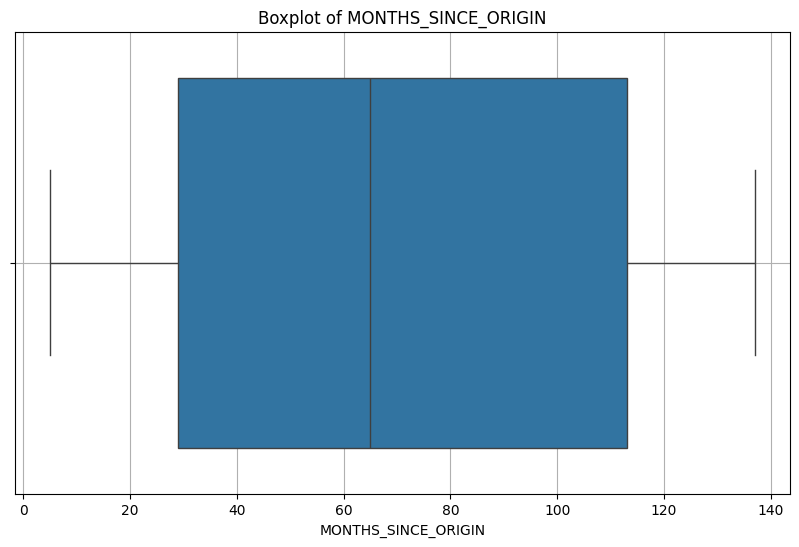

Number of Outliers in MONTHS_SINCE_ORIGIN: 0
Summary Statistics for DONOR_AGE:
count    14577.000000
mean        58.919051
std         16.669382
min          0.000000
25%         47.000000
50%         60.000000
75%         73.000000
max         87.000000
Name: DONOR_AGE, dtype: float64


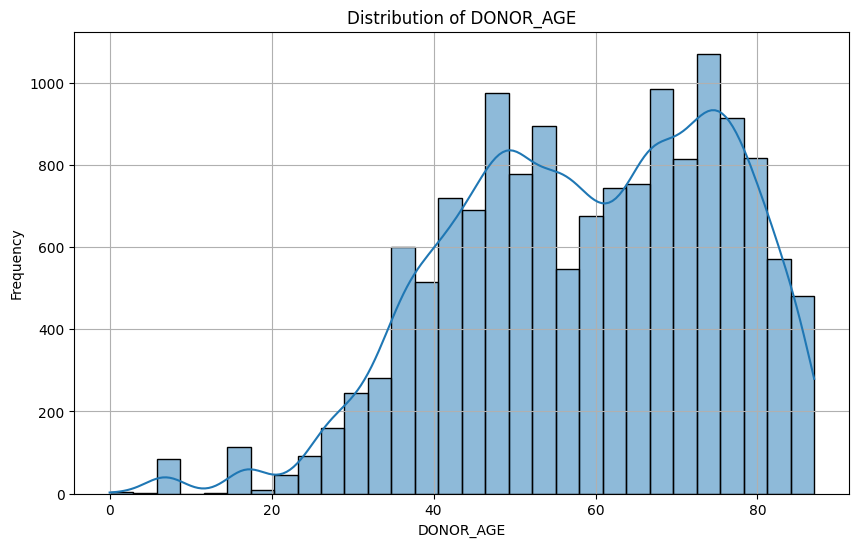

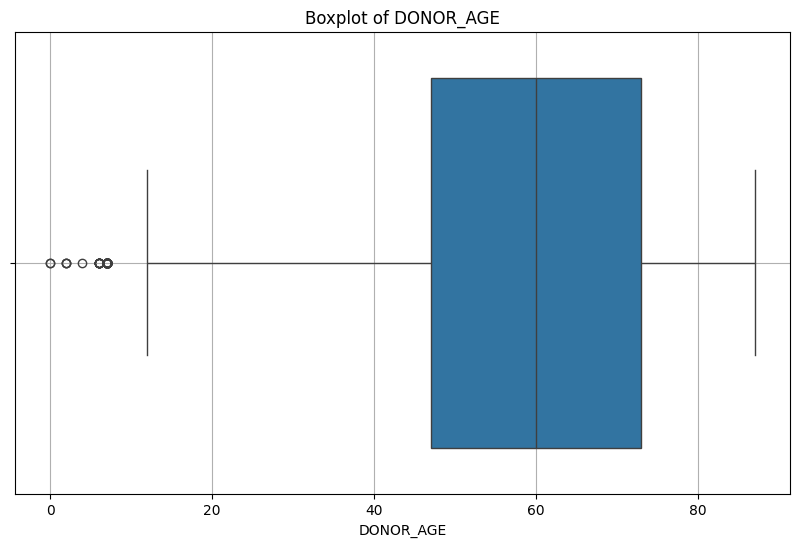

Number of Outliers in DONOR_AGE: 90
Summary Statistics for IN_HOUSE:
count    19372.000000
mean         0.073198
std          0.260469
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: IN_HOUSE, dtype: float64


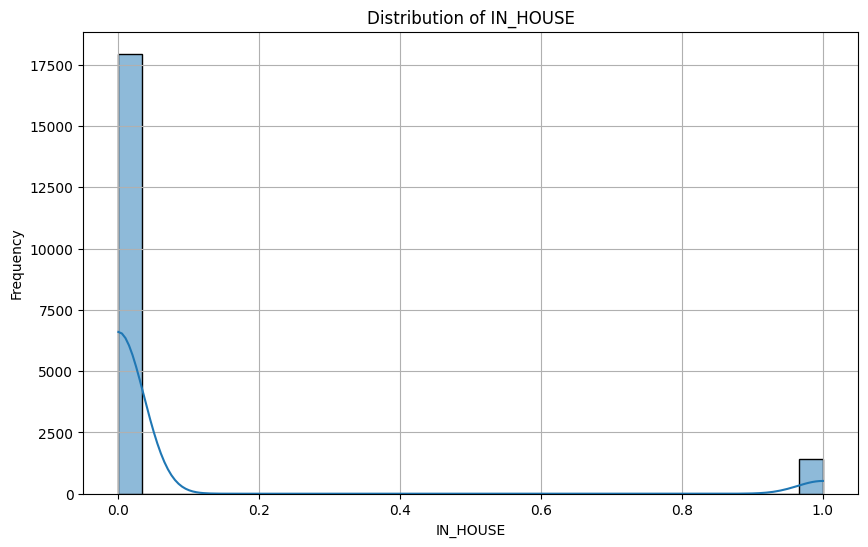

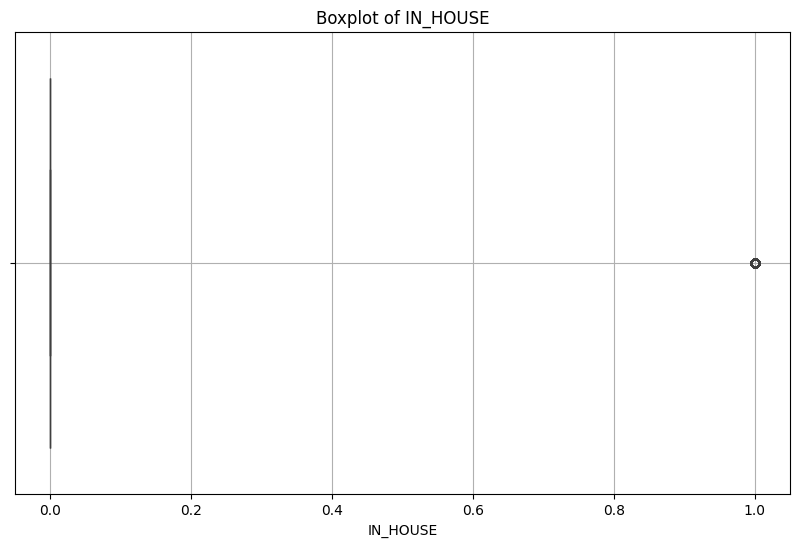

Number of Outliers in IN_HOUSE: 1418
Summary Statistics for INCOME_GROUP:
count    14980.000000
mean         3.907543
std          1.864796
min          1.000000
25%          2.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: INCOME_GROUP, dtype: float64


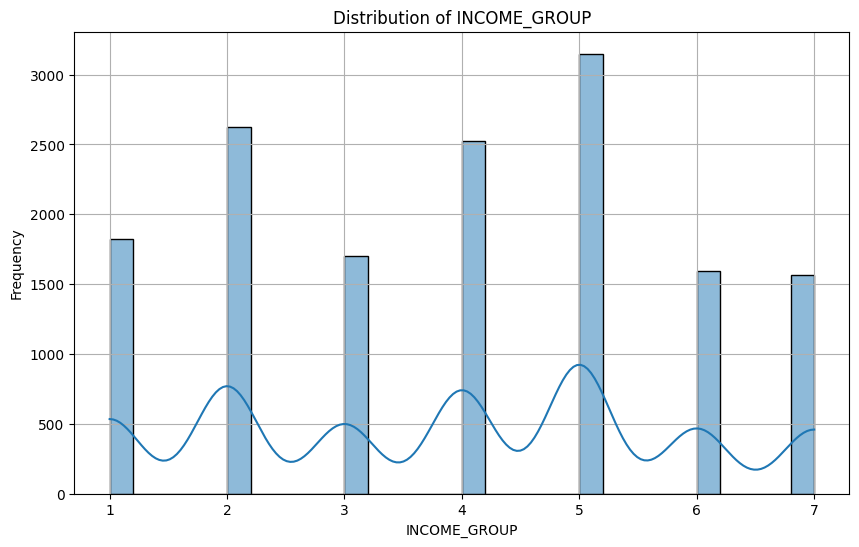

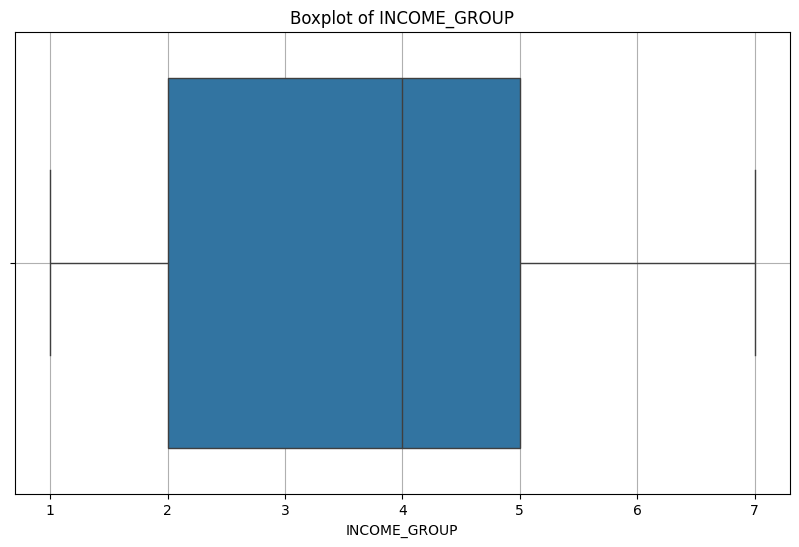

Number of Outliers in INCOME_GROUP: 0
Summary Statistics for PUBLISHED_PHONE:
count    19372.000000
mean         0.497729
std          0.500008
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: PUBLISHED_PHONE, dtype: float64


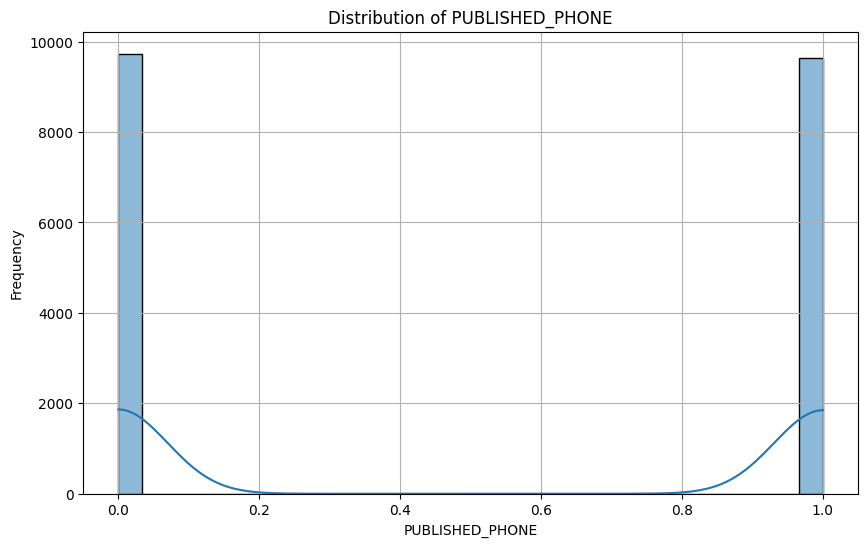

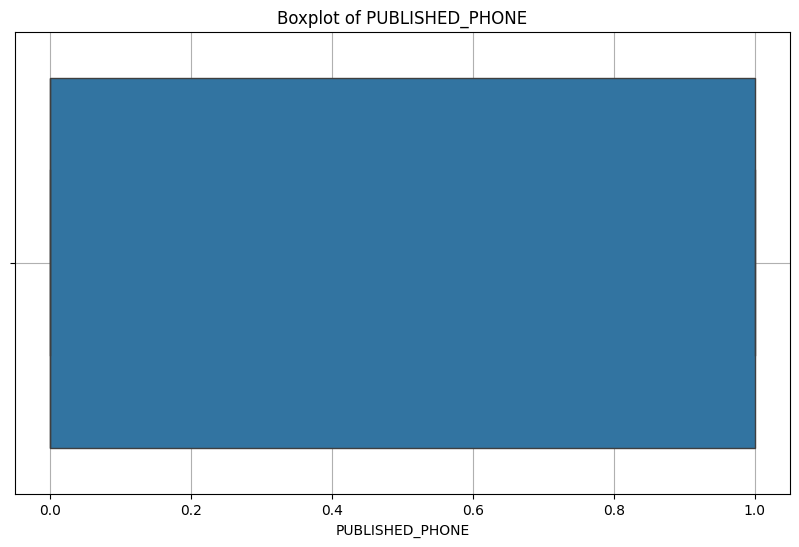

Number of Outliers in PUBLISHED_PHONE: 0
Summary Statistics for MOR_HIT_RATE:
count    19372.000000
mean         3.361656
std          9.503481
min          0.000000
25%          0.000000
50%          0.000000
75%          3.000000
max        241.000000
Name: MOR_HIT_RATE, dtype: float64


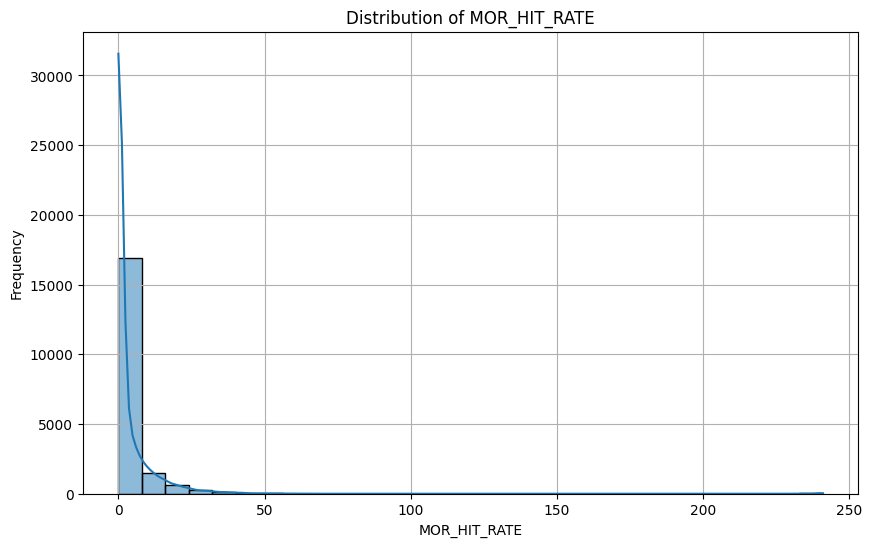

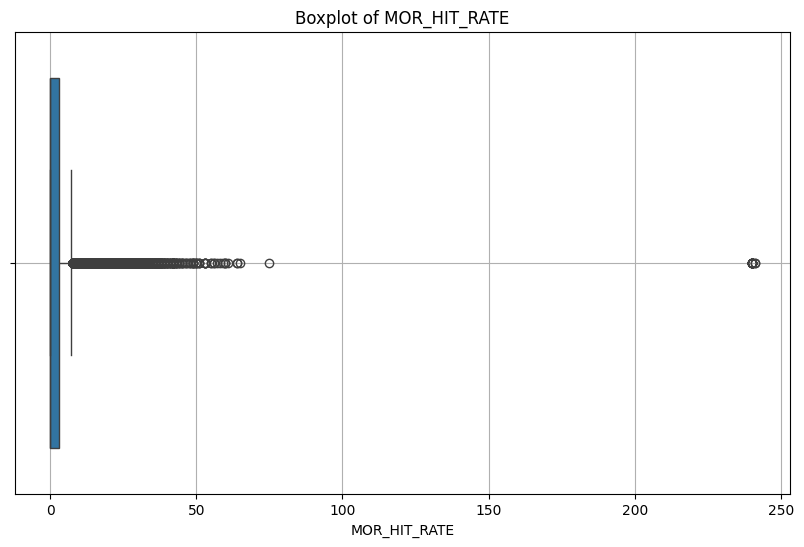

Number of Outliers in MOR_HIT_RATE: 2785
Summary Statistics for WEALTH_RATING:
count    10562.000000
mean         5.005397
std          2.815386
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max          9.000000
Name: WEALTH_RATING, dtype: float64


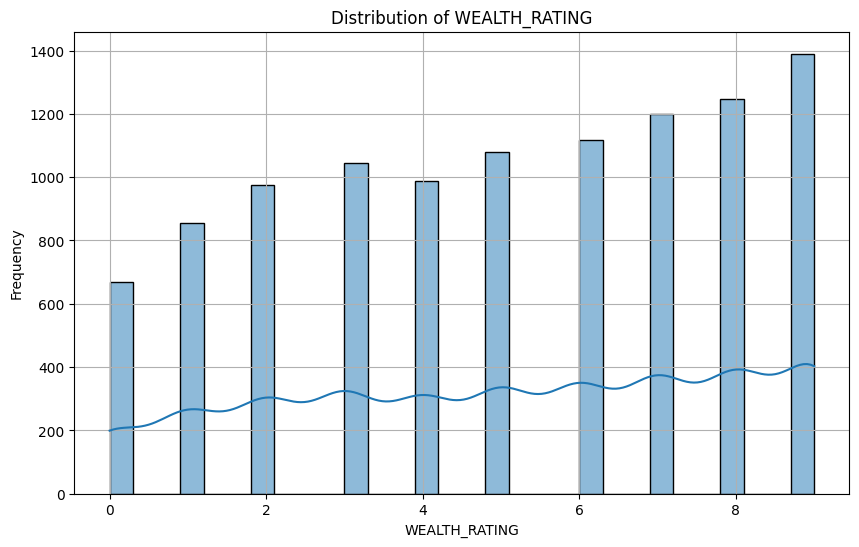

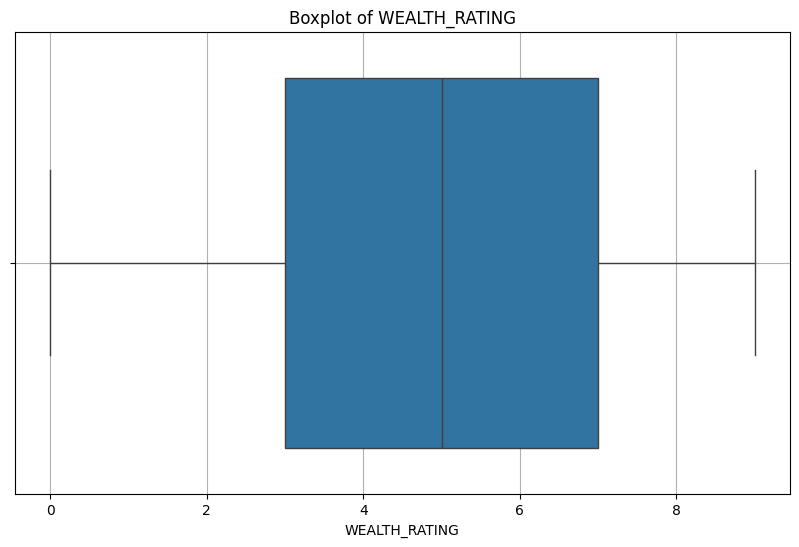

Number of Outliers in WEALTH_RATING: 0
Summary Statistics for MEDIAN_HOME_VALUE:
count    19372.000000
mean      1079.871929
std        960.753448
min          0.000000
25%        518.000000
50%        747.000000
75%       1227.000000
max       6000.000000
Name: MEDIAN_HOME_VALUE, dtype: float64


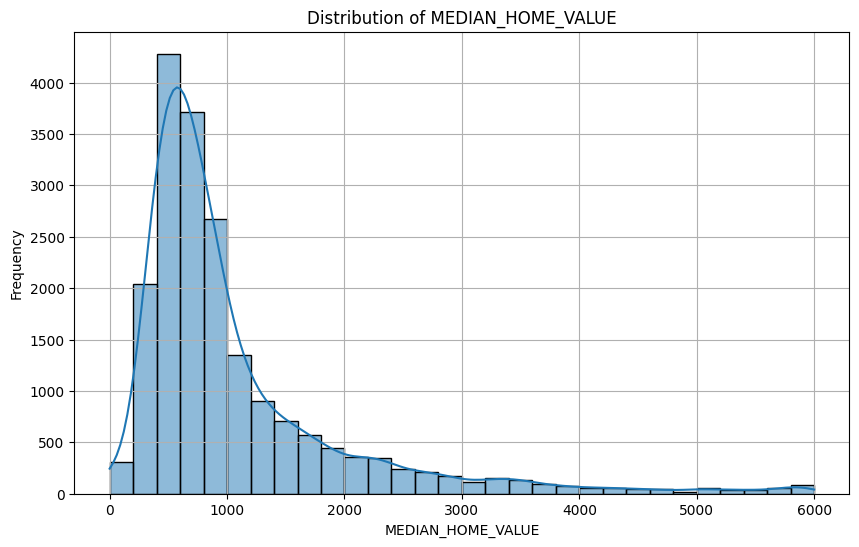

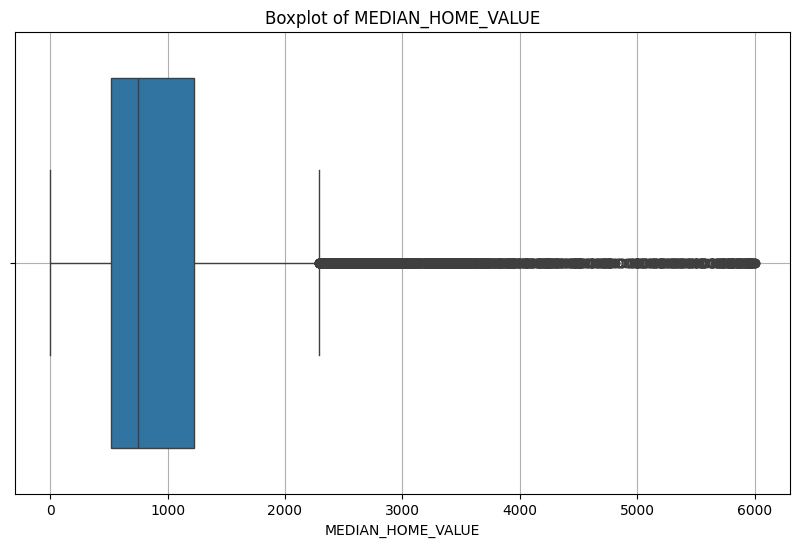

Number of Outliers in MEDIAN_HOME_VALUE: 1874
Summary Statistics for MEDIAN_HOUSEHOLD_INCOME:
count    19372.000000
mean       341.970215
std        164.207807
min          0.000000
25%        232.000000
50%        311.000000
75%        417.000000
max       1500.000000
Name: MEDIAN_HOUSEHOLD_INCOME, dtype: float64


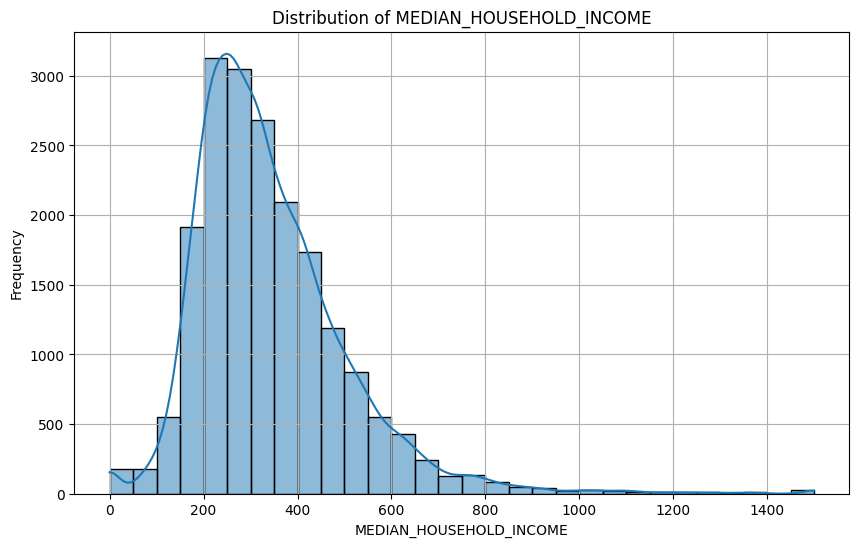

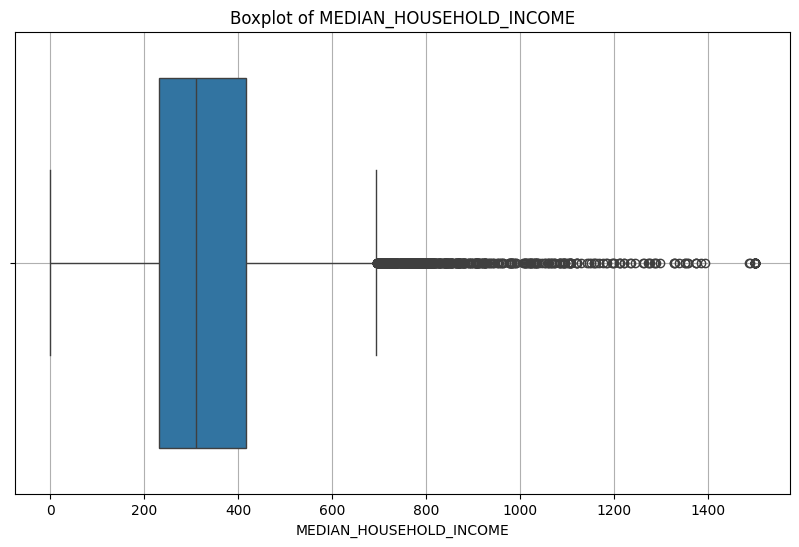

Number of Outliers in MEDIAN_HOUSEHOLD_INCOME: 606
Summary Statistics for PCT_OWNER_OCCUPIED:
count    19372.000000
mean        69.698999
std         21.711019
min          0.000000
25%         60.000000
50%         76.000000
75%         85.000000
max         99.000000
Name: PCT_OWNER_OCCUPIED, dtype: float64


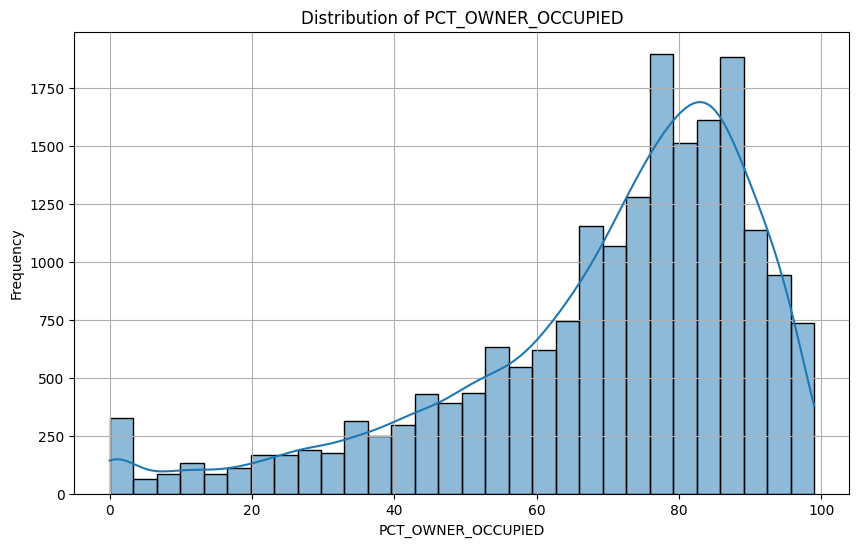

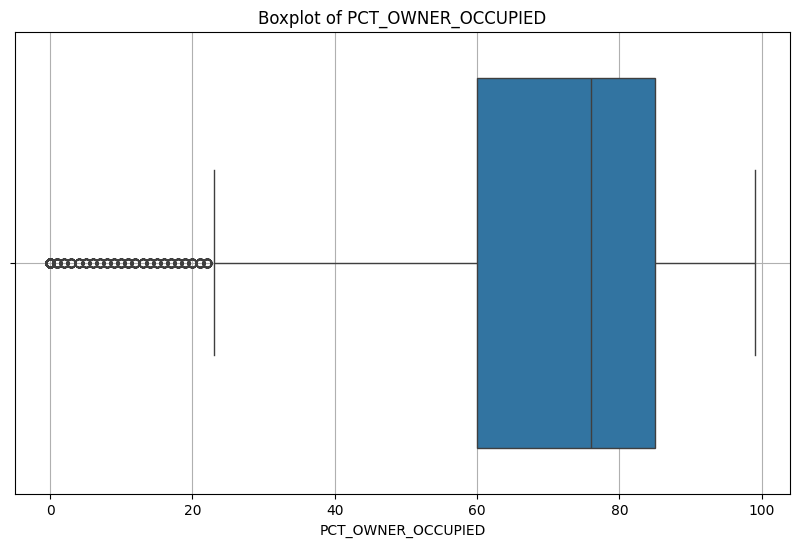

Number of Outliers in PCT_OWNER_OCCUPIED: 921
Summary Statistics for PER_CAPITA_INCOME:
count     19372.000000
mean      15857.334452
std        8710.630390
min           0.000000
25%       10869.000000
50%       13816.500000
75%       18308.250000
max      174523.000000
Name: PER_CAPITA_INCOME, dtype: float64


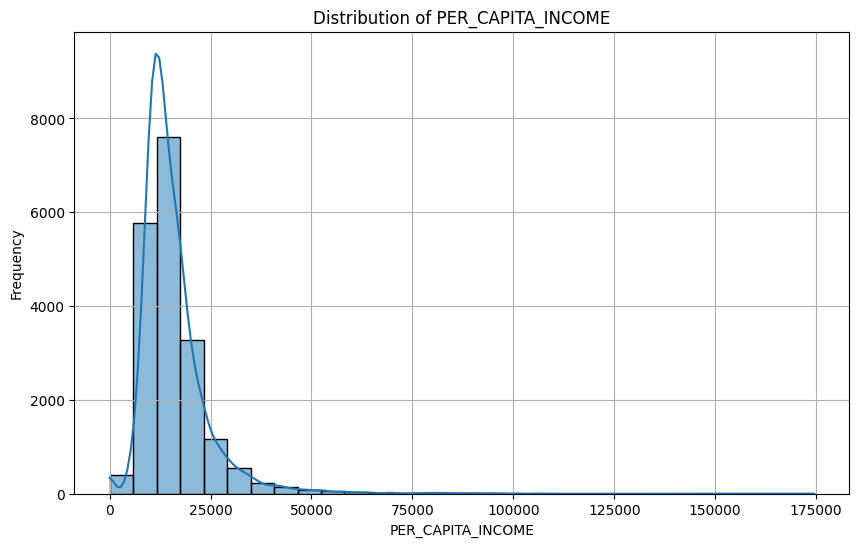

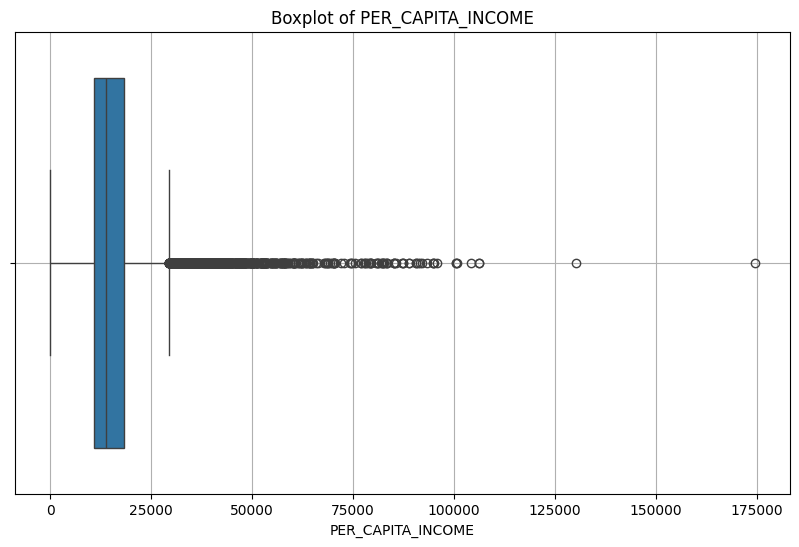

Number of Outliers in PER_CAPITA_INCOME: 1108
Summary Statistics for PCT_ATTRIBUTE1:
count    19372.000000
mean         1.029011
std          4.918297
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         97.000000
Name: PCT_ATTRIBUTE1, dtype: float64


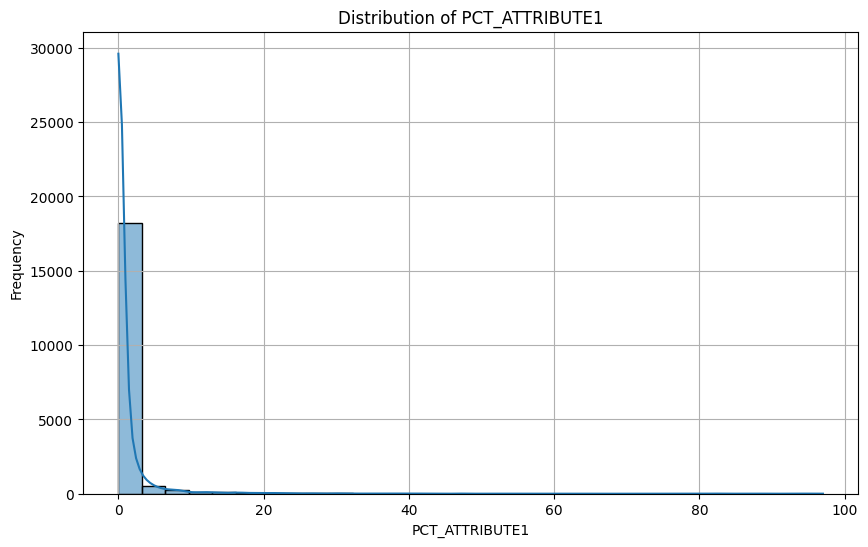

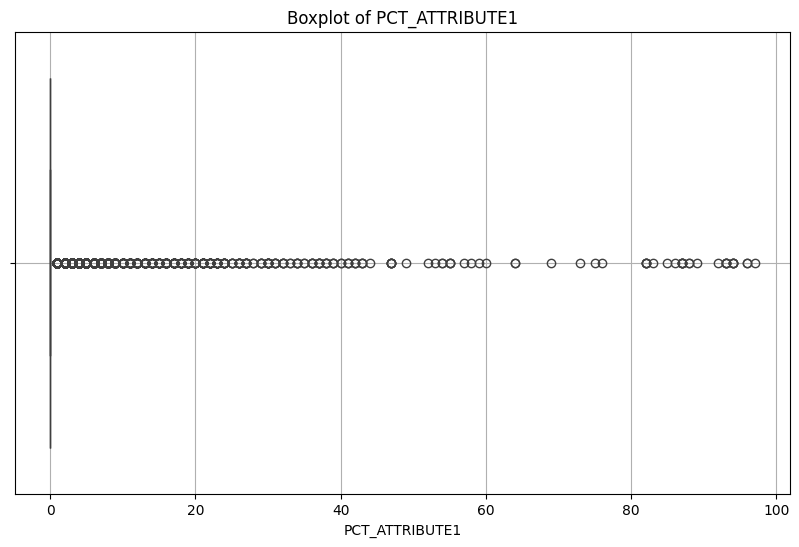

Number of Outliers in PCT_ATTRIBUTE1: 4364
Summary Statistics for PCT_ATTRIBUTE2:
count    19372.000000
mean        30.573921
std         11.421471
min          0.000000
25%         25.000000
50%         31.000000
75%         37.000000
max         99.000000
Name: PCT_ATTRIBUTE2, dtype: float64


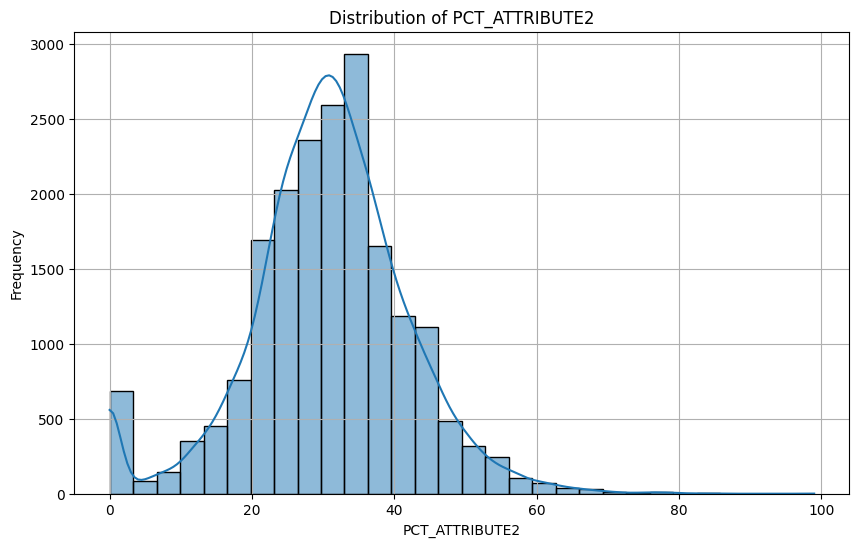

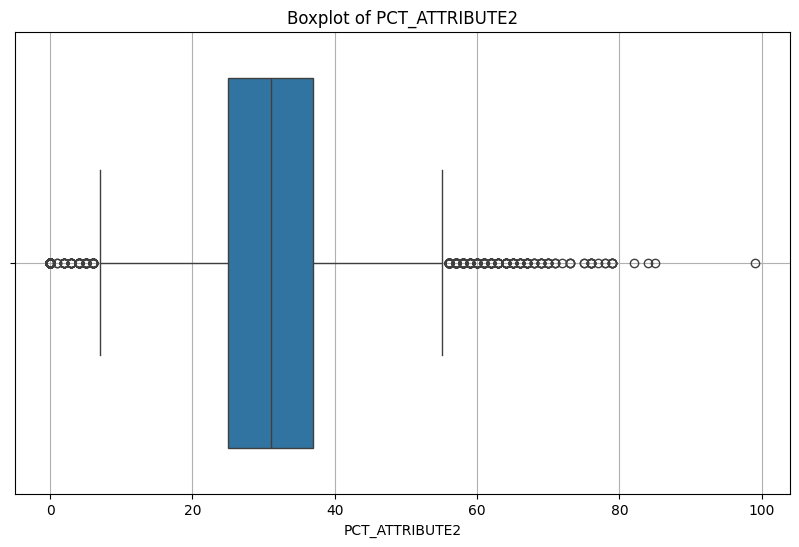

Number of Outliers in PCT_ATTRIBUTE2: 1107
Summary Statistics for PCT_ATTRIBUTE3:
count    19372.000000
mean        29.603293
std         15.120360
min          0.000000
25%         20.000000
50%         29.000000
75%         39.000000
max         99.000000
Name: PCT_ATTRIBUTE3, dtype: float64


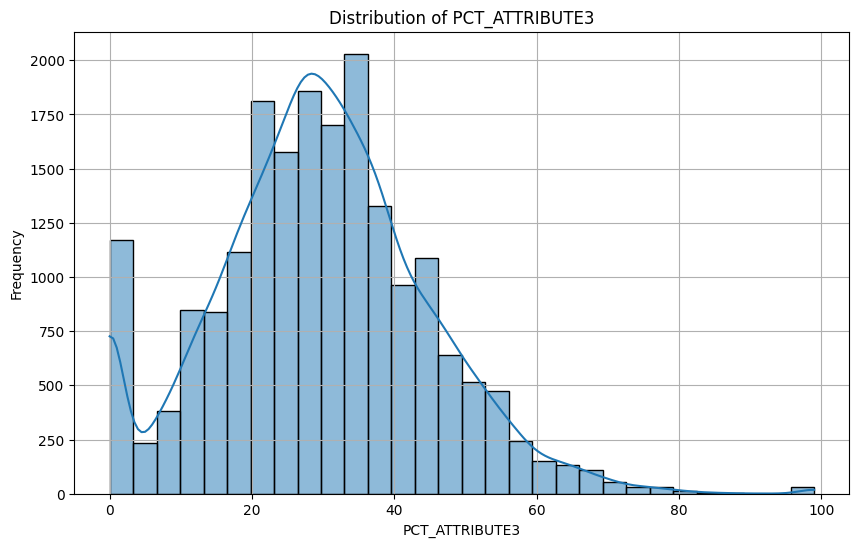

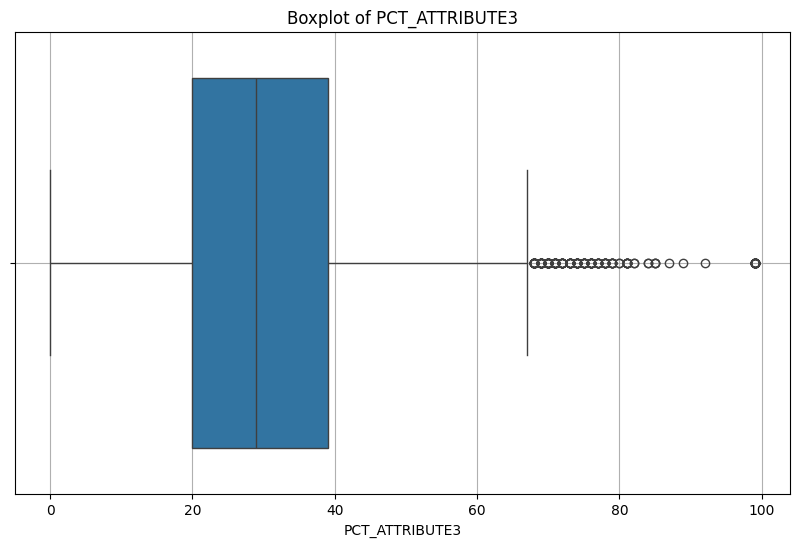

Number of Outliers in PCT_ATTRIBUTE3: 213
Summary Statistics for PCT_ATTRIBUTE4:
count    19372.000000
mean        32.852467
std         17.839765
min          0.000000
25%         21.000000
50%         32.000000
75%         43.000000
max         99.000000
Name: PCT_ATTRIBUTE4, dtype: float64


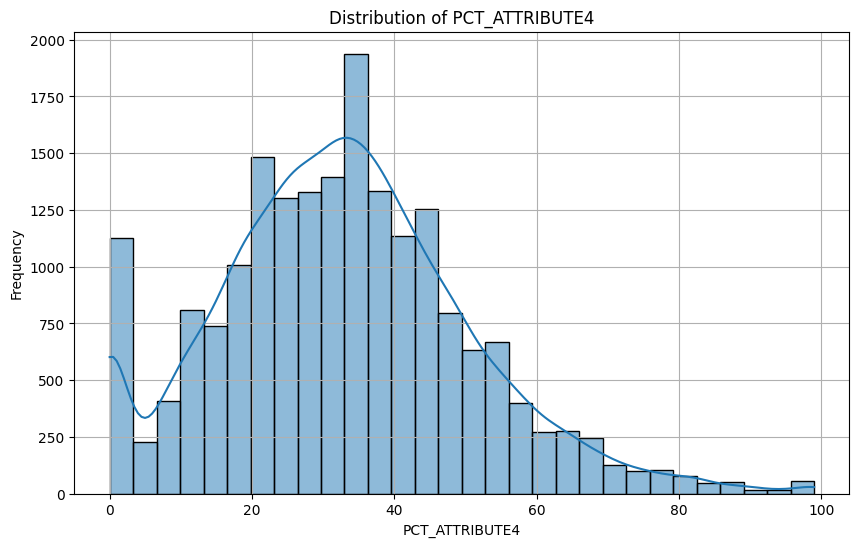

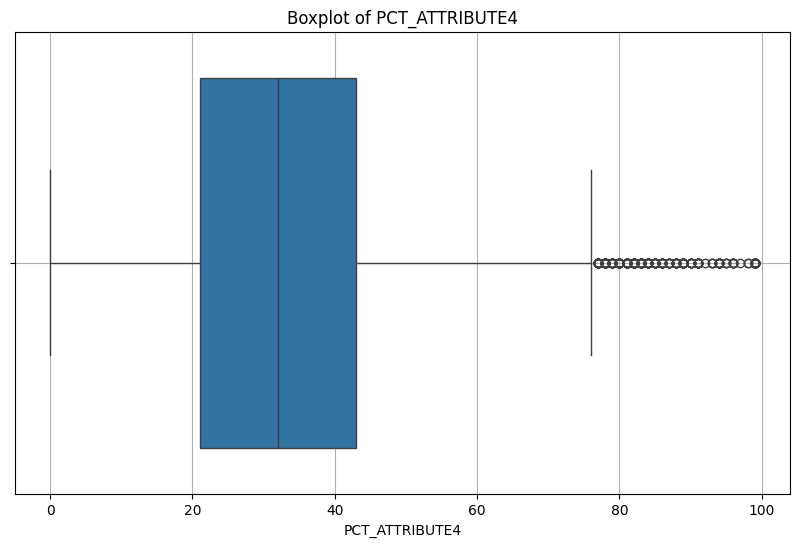

Number of Outliers in PCT_ATTRIBUTE4: 341
Summary Statistics for PEP_STAR:
count    19372.000000
mean         0.504439
std          0.499993
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: PEP_STAR, dtype: float64


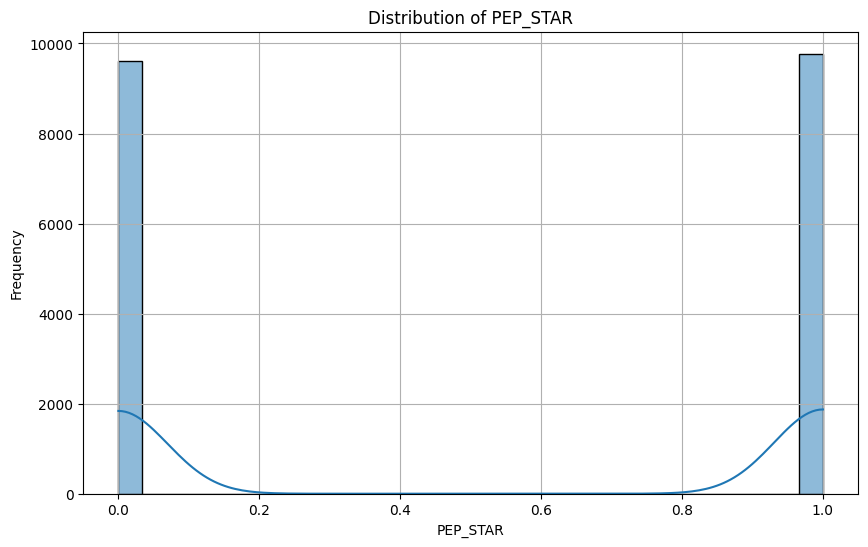

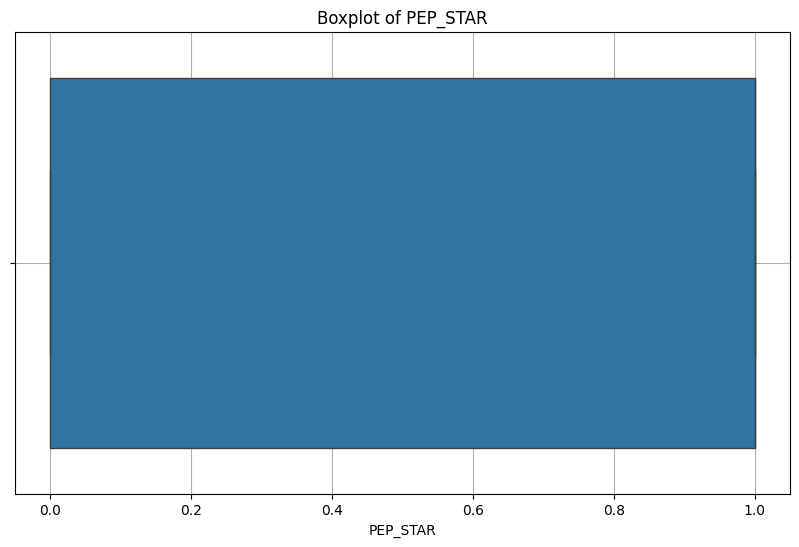

Number of Outliers in PEP_STAR: 0
Summary Statistics for RECENT_STAR_STATUS:
count    19372.000000
mean         0.931138
std          2.545585
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         22.000000
Name: RECENT_STAR_STATUS, dtype: float64


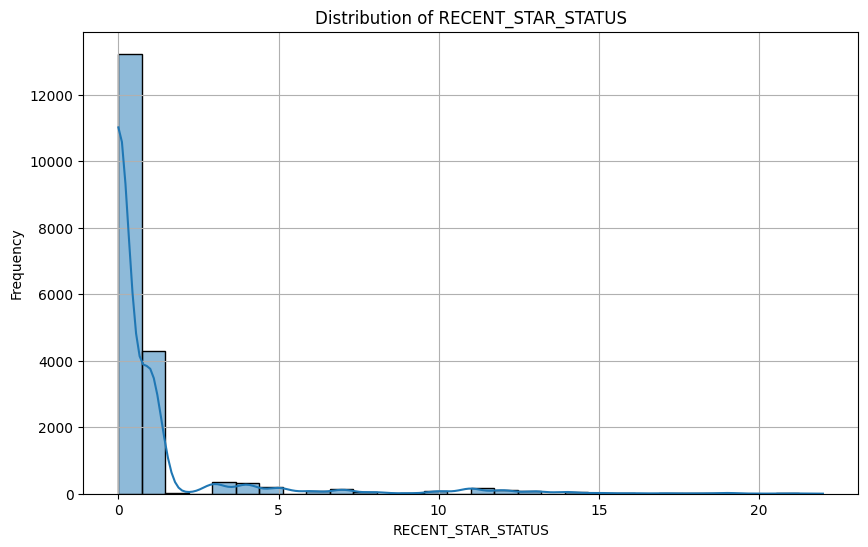

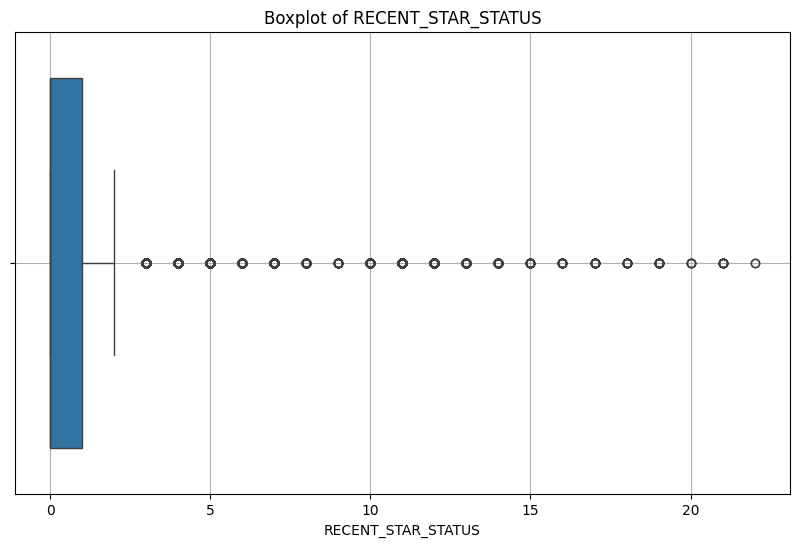

Number of Outliers in RECENT_STAR_STATUS: 1818
Summary Statistics for FREQUENCY_STATUS_97NK:
count    19372.000000
mean         1.983998
std          1.099346
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: FREQUENCY_STATUS_97NK, dtype: float64


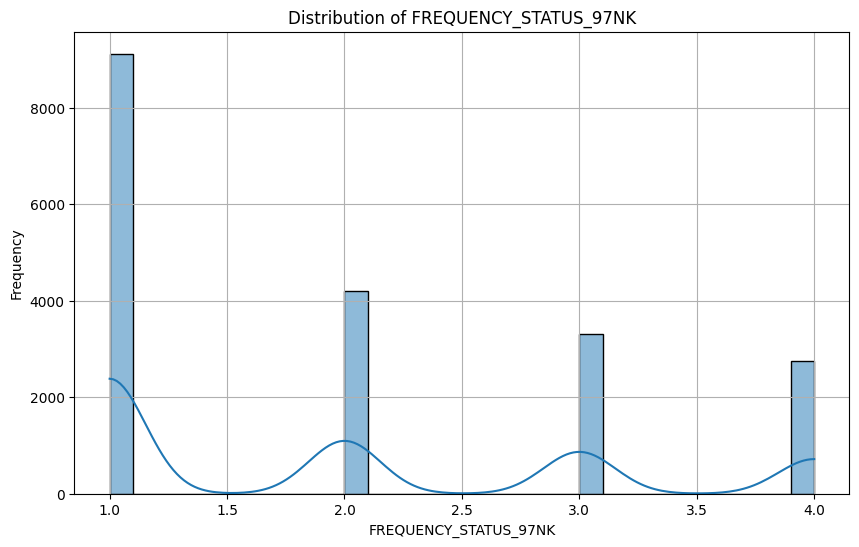

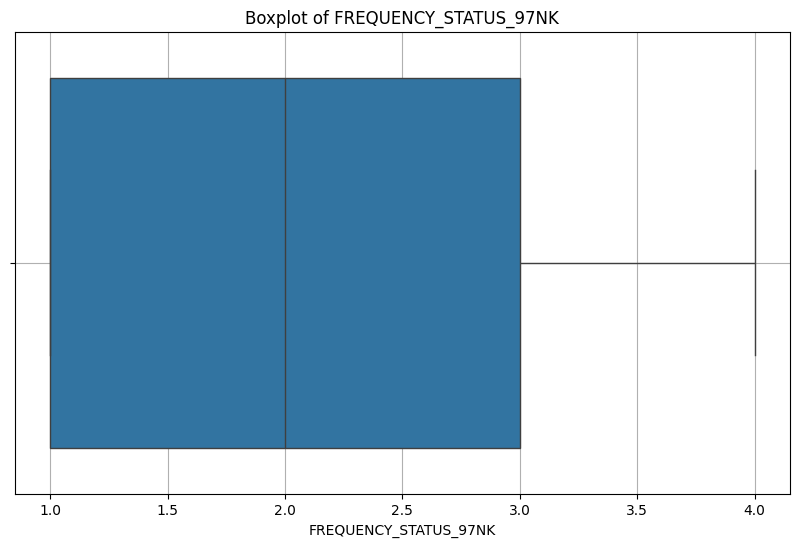

Number of Outliers in FREQUENCY_STATUS_97NK: 0
Summary Statistics for RECENT_RESPONSE_PROP:
count    19372.000000
mean         0.190127
std          0.113947
min          0.000000
25%          0.105000
50%          0.167000
75%          0.250000
max          1.000000
Name: RECENT_RESPONSE_PROP, dtype: float64


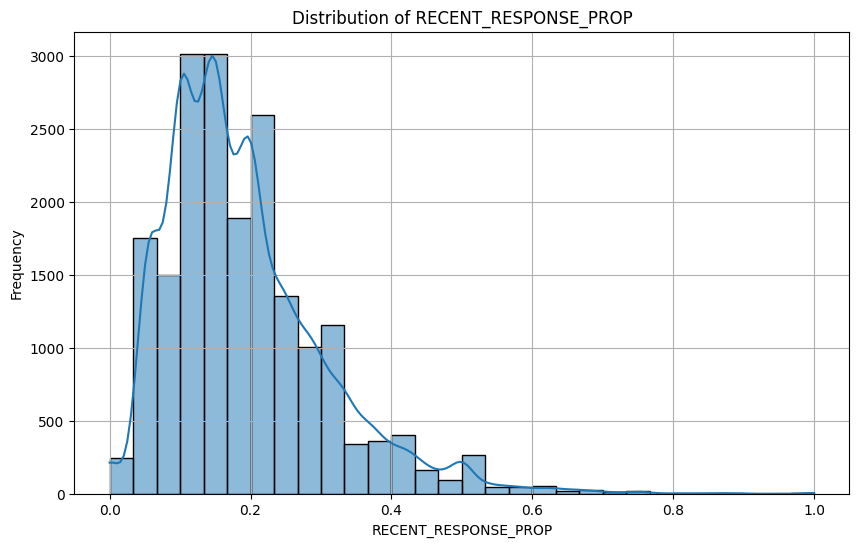

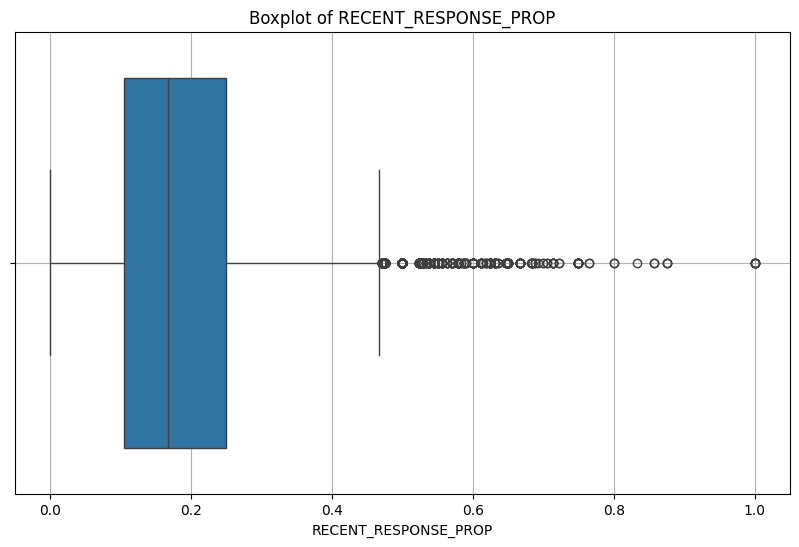

Number of Outliers in RECENT_RESPONSE_PROP: 585
Summary Statistics for RECENT_AVG_GIFT_AMT:
count    19372.000000
mean        15.365396
std         10.167485
min          0.000000
25%         10.000000
50%         14.000000
75%         20.000000
max        260.000000
Name: RECENT_AVG_GIFT_AMT, dtype: float64


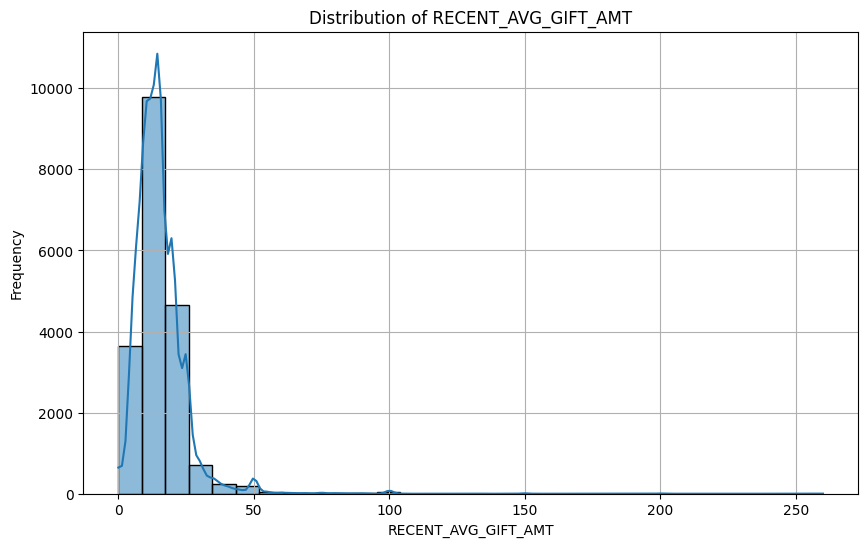

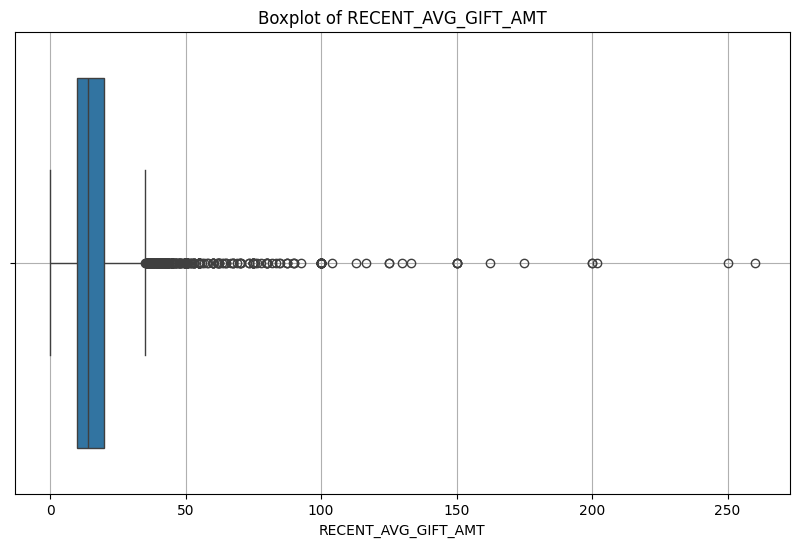

Number of Outliers in RECENT_AVG_GIFT_AMT: 510
Summary Statistics for RECENT_CARD_RESPONSE_PROP:
count    19372.000000
mean         0.230808
std          0.186230
min          0.000000
25%          0.100000
50%          0.200000
75%          0.333000
max          1.000000
Name: RECENT_CARD_RESPONSE_PROP, dtype: float64


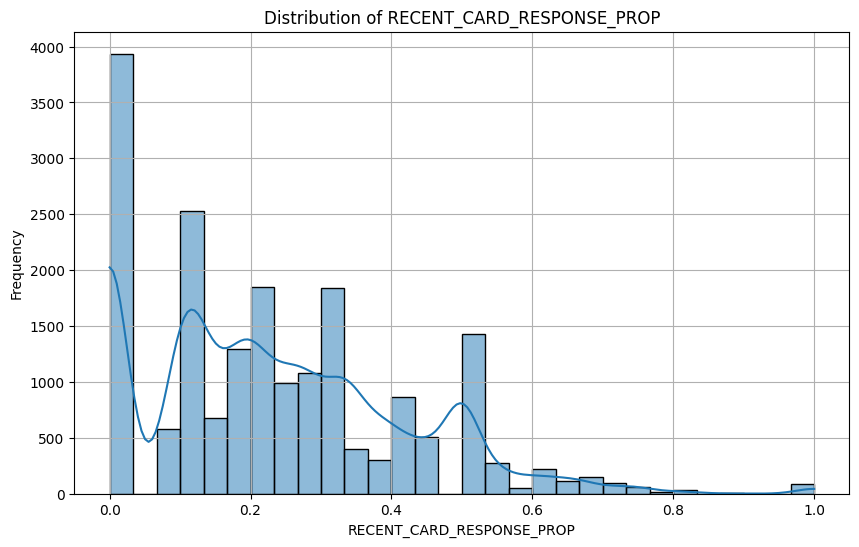

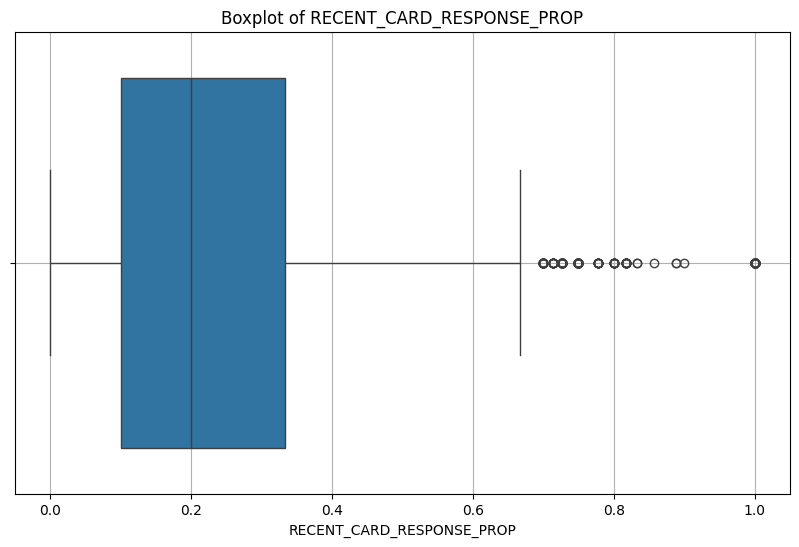

Number of Outliers in RECENT_CARD_RESPONSE_PROP: 294
Summary Statistics for RECENT_AVG_CARD_GIFT_AMT:
count    19372.00000
mean        11.68547
std         10.83412
min          0.00000
25%          5.00000
50%         10.14000
75%         16.00000
max        300.00000
Name: RECENT_AVG_CARD_GIFT_AMT, dtype: float64


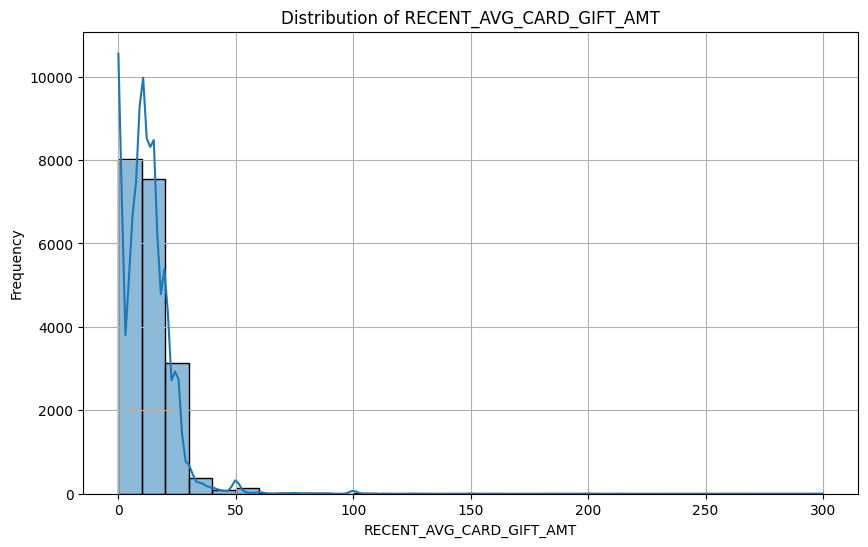

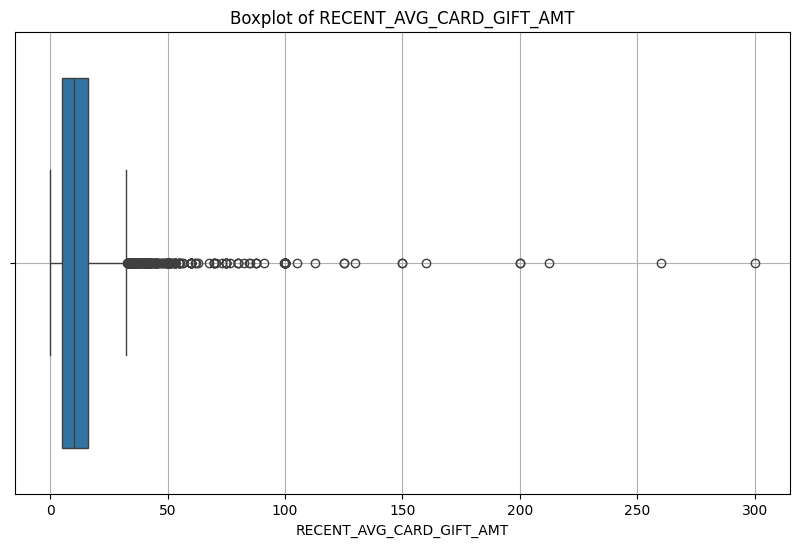

Number of Outliers in RECENT_AVG_CARD_GIFT_AMT: 433
Summary Statistics for RECENT_RESPONSE_COUNT:
count    19372.000000
mean         3.043103
std          2.046401
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         16.000000
Name: RECENT_RESPONSE_COUNT, dtype: float64


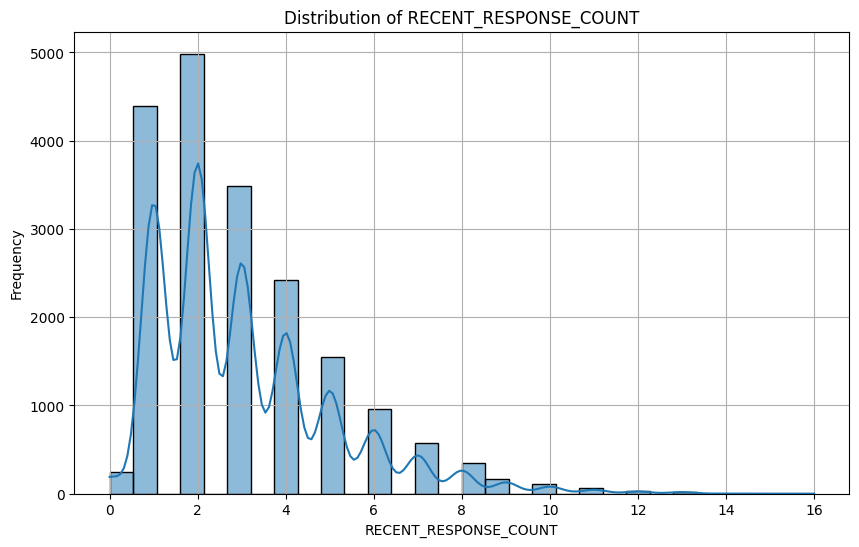

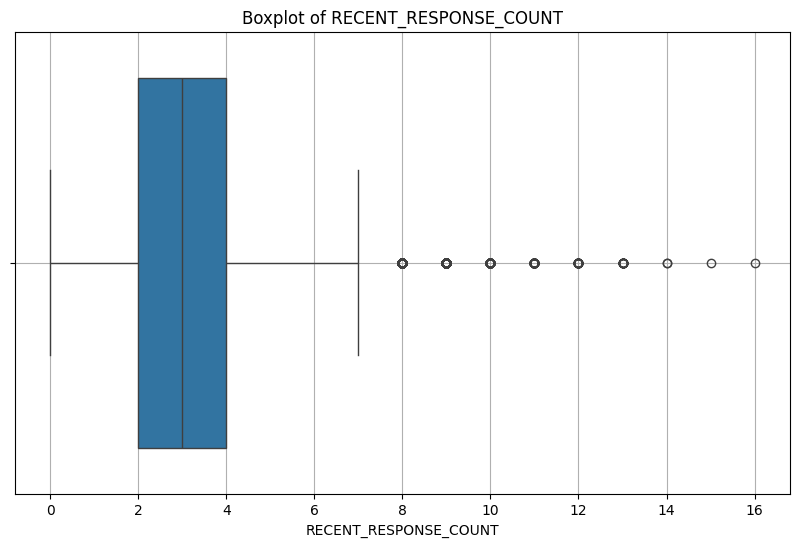

Number of Outliers in RECENT_RESPONSE_COUNT: 751
Summary Statistics for RECENT_CARD_RESPONSE_COUNT:
count    19372.000000
mean         1.730539
std          1.535521
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          9.000000
Name: RECENT_CARD_RESPONSE_COUNT, dtype: float64


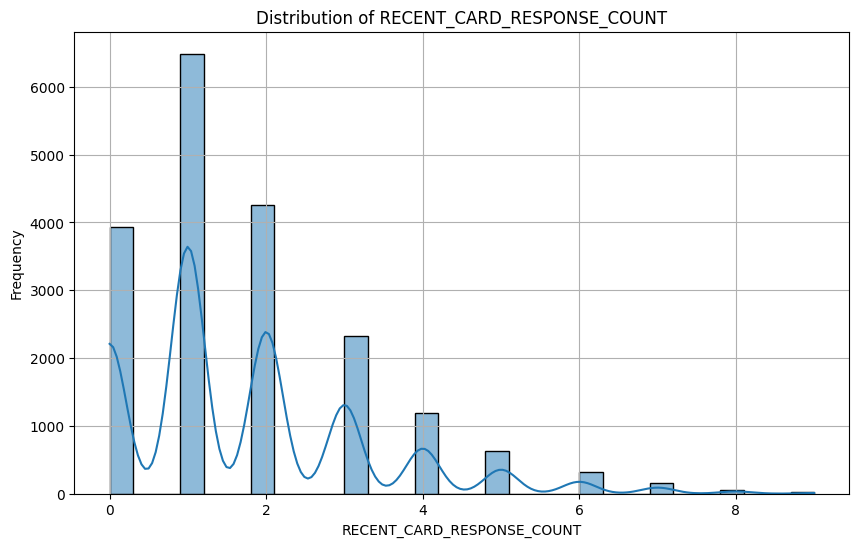

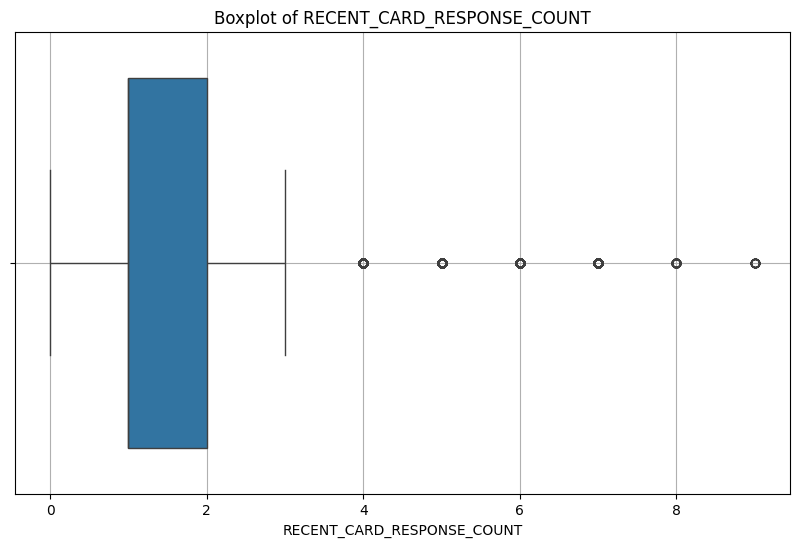

Number of Outliers in RECENT_CARD_RESPONSE_COUNT: 2368
Summary Statistics for MONTHS_SINCE_LAST_PROM_RESP:
count    19126.000000
mean        19.038900
std          3.415559
min        -12.000000
25%         17.000000
50%         18.000000
75%         21.000000
max         36.000000
Name: MONTHS_SINCE_LAST_PROM_RESP, dtype: float64


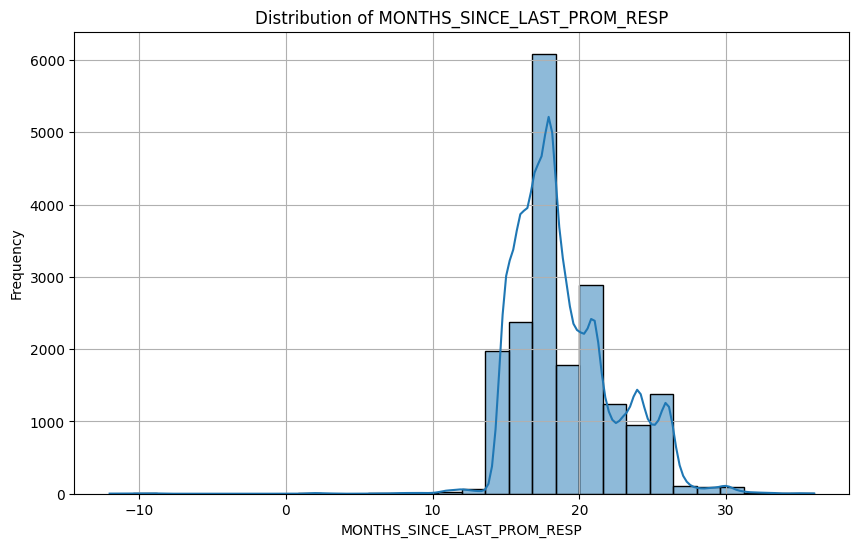

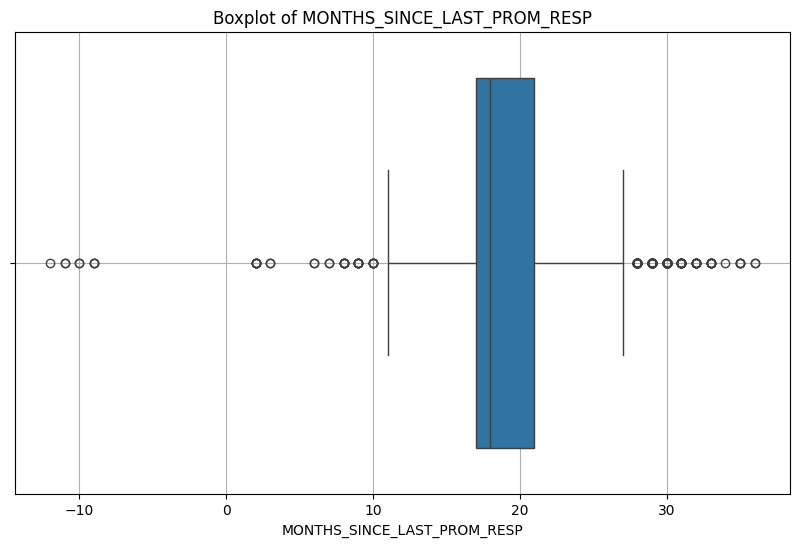

Number of Outliers in MONTHS_SINCE_LAST_PROM_RESP: 247
Summary Statistics for LIFETIME_CARD_PROM:
count    19372.000000
mean        18.668078
std          8.558778
min          2.000000
25%         11.000000
50%         18.000000
75%         26.000000
max         56.000000
Name: LIFETIME_CARD_PROM, dtype: float64


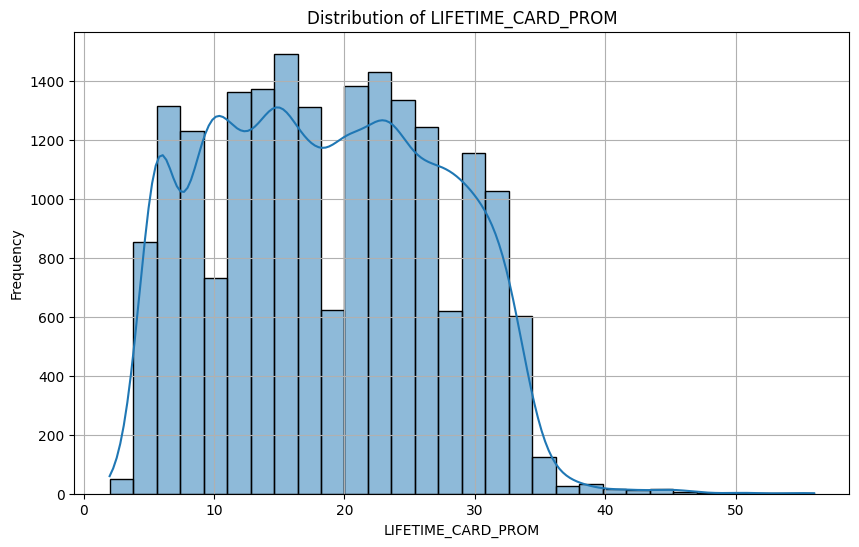

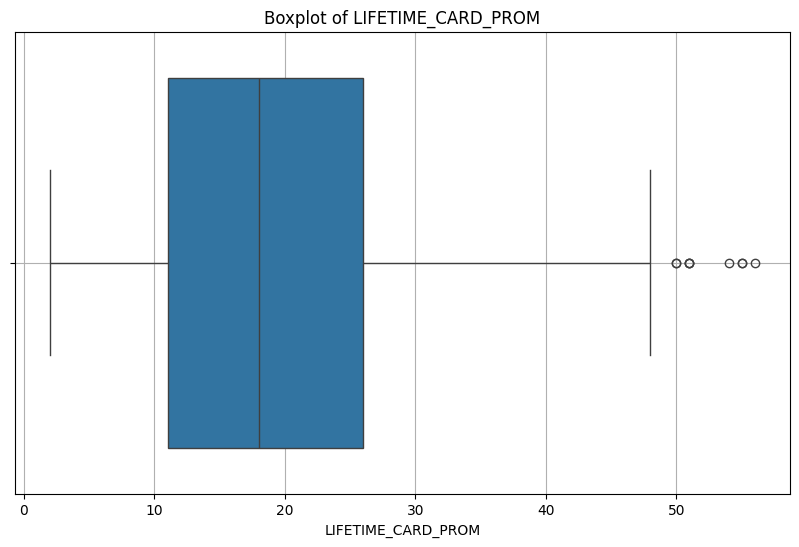

Number of Outliers in LIFETIME_CARD_PROM: 9
Summary Statistics for LIFETIME_PROM:
count    19372.000000
mean        47.570514
std         22.950158
min          5.000000
25%         28.000000
50%         47.000000
75%         64.000000
max        194.000000
Name: LIFETIME_PROM, dtype: float64


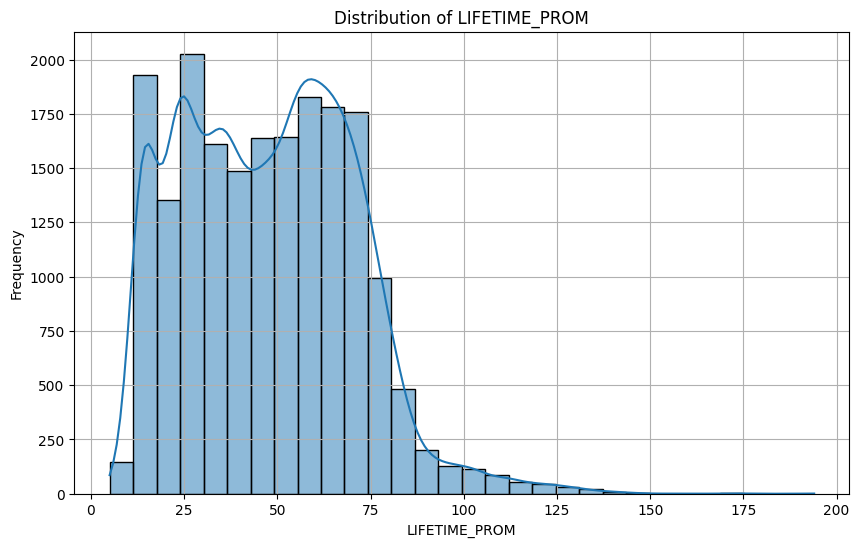

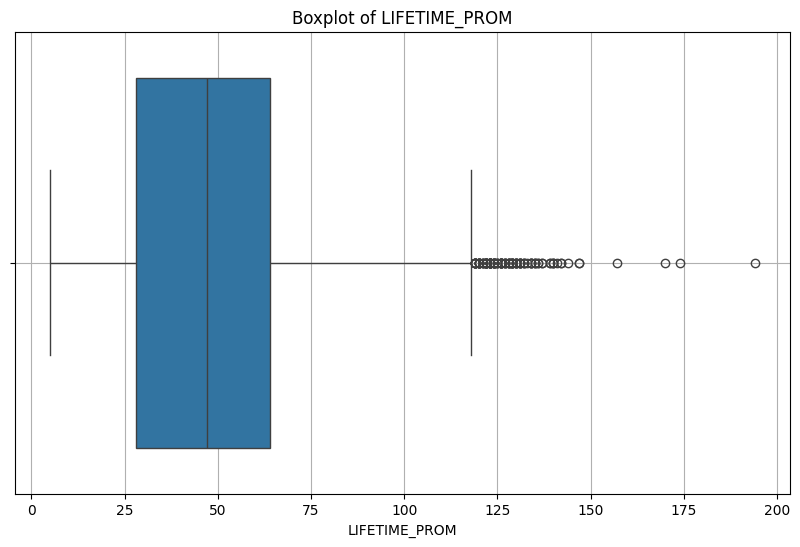

Number of Outliers in LIFETIME_PROM: 111
Summary Statistics for LIFETIME_GIFT_AMOUNT:
count    19372.000000
mean       104.425716
std        105.722460
min         15.000000
25%         42.000000
50%         79.000000
75%        132.000000
max       3775.000000
Name: LIFETIME_GIFT_AMOUNT, dtype: float64


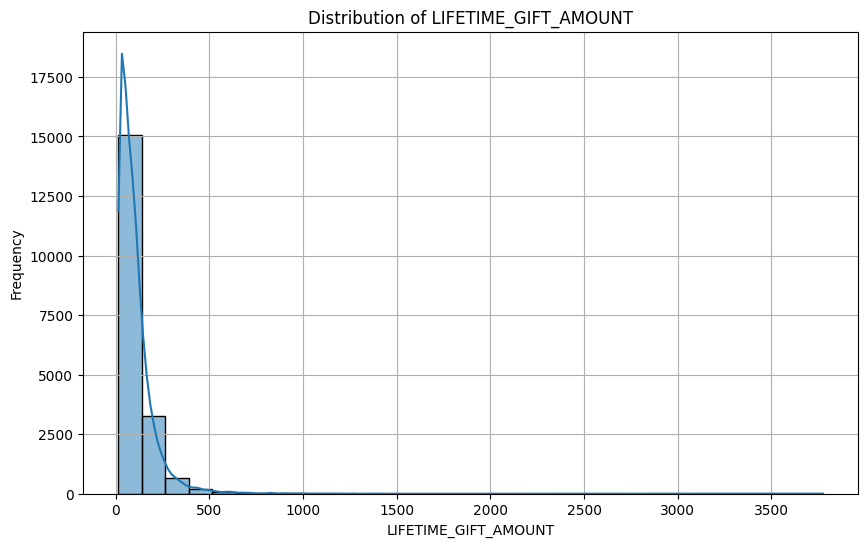

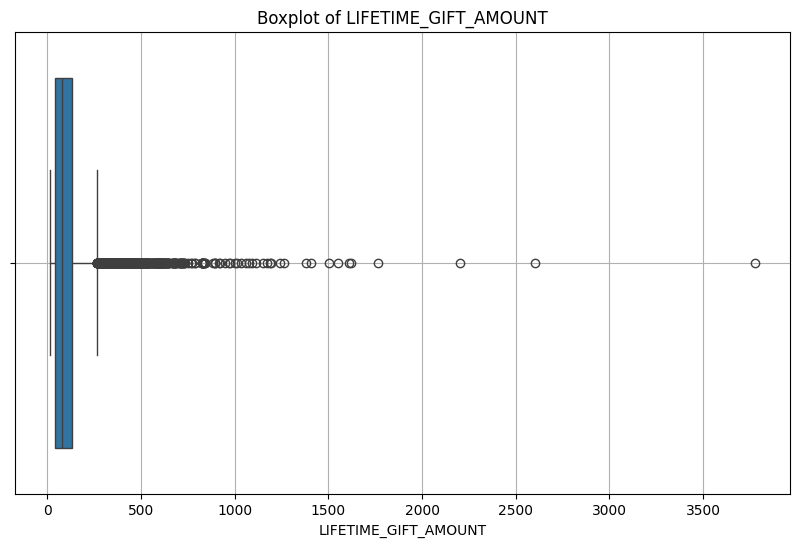

Number of Outliers in LIFETIME_GIFT_AMOUNT: 994
Summary Statistics for LIFETIME_GIFT_COUNT:
count    19372.000000
mean         9.979765
std          8.688163
min          1.000000
25%          4.000000
50%          8.000000
75%         14.000000
max         95.000000
Name: LIFETIME_GIFT_COUNT, dtype: float64


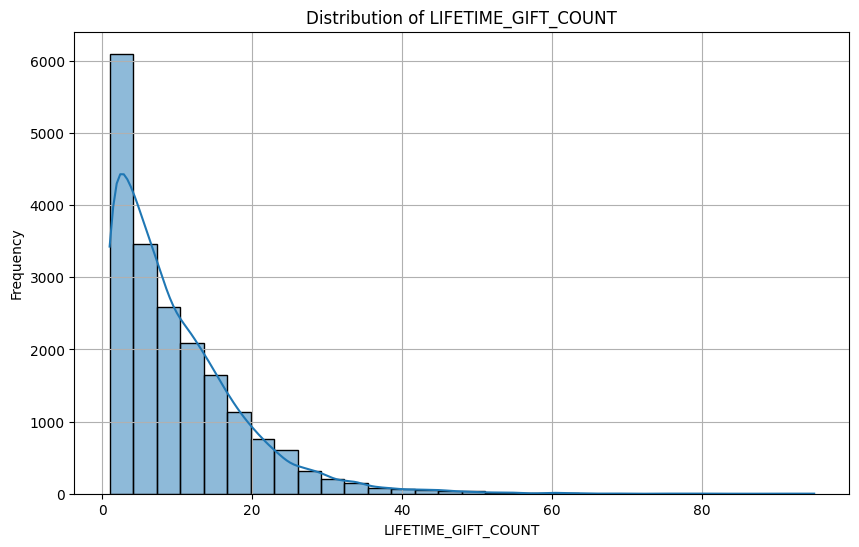

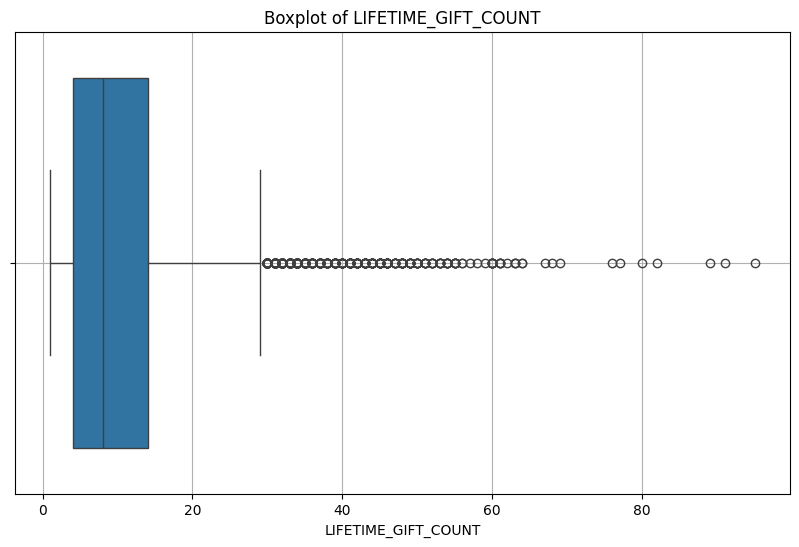

Number of Outliers in LIFETIME_GIFT_COUNT: 677
Summary Statistics for LIFETIME_AVG_GIFT_AMT:
count    19372.000000
mean        12.858338
std          8.787758
min          1.360000
25%          8.000000
50%         11.200000
75%         15.000000
max        450.000000
Name: LIFETIME_AVG_GIFT_AMT, dtype: float64


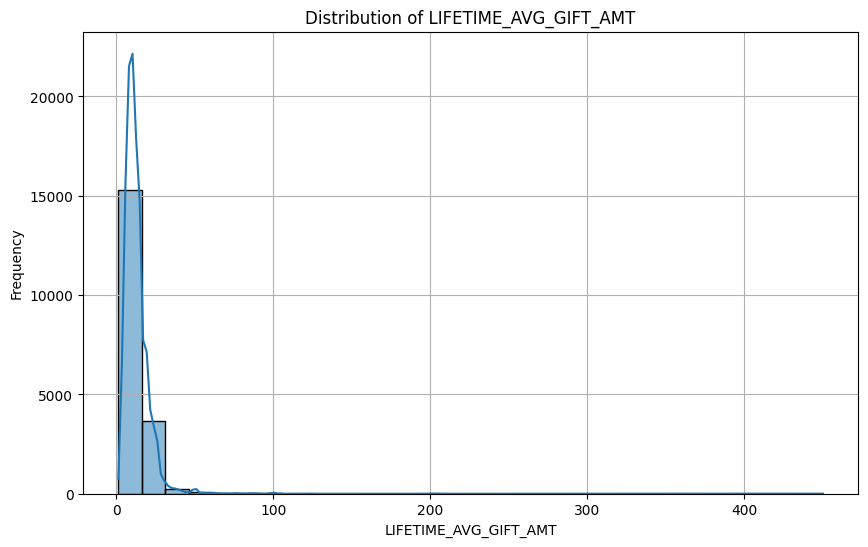

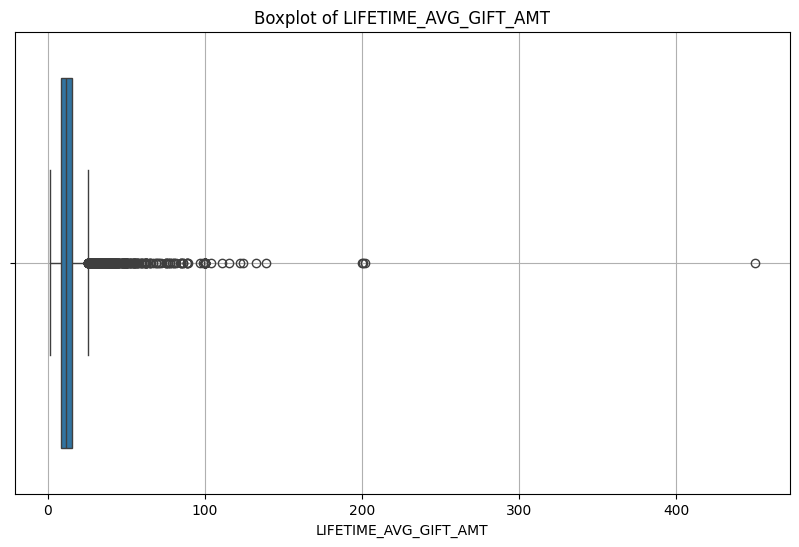

Number of Outliers in LIFETIME_AVG_GIFT_AMT: 731
Summary Statistics for LIFETIME_GIFT_RANGE:
count    19372.000000
mean        11.587876
std         15.116893
min          0.000000
25%          5.000000
50%         10.000000
75%         15.000000
max        997.000000
Name: LIFETIME_GIFT_RANGE, dtype: float64


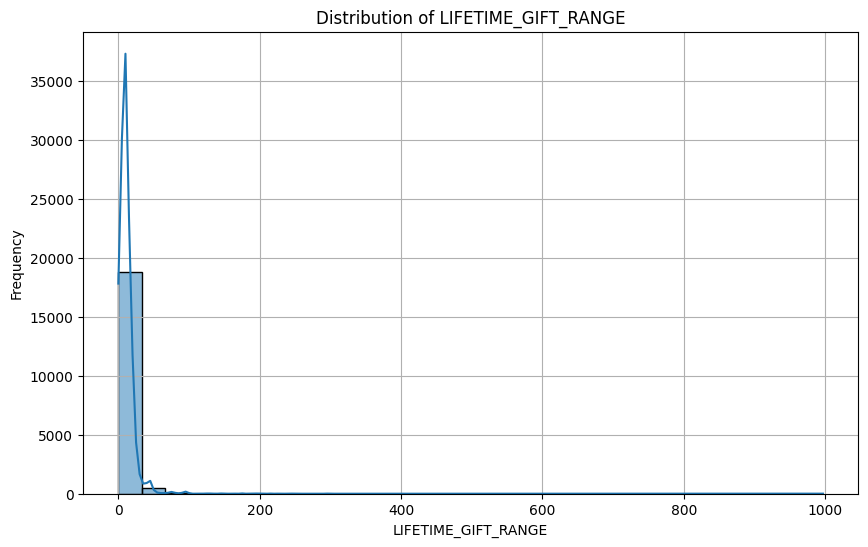

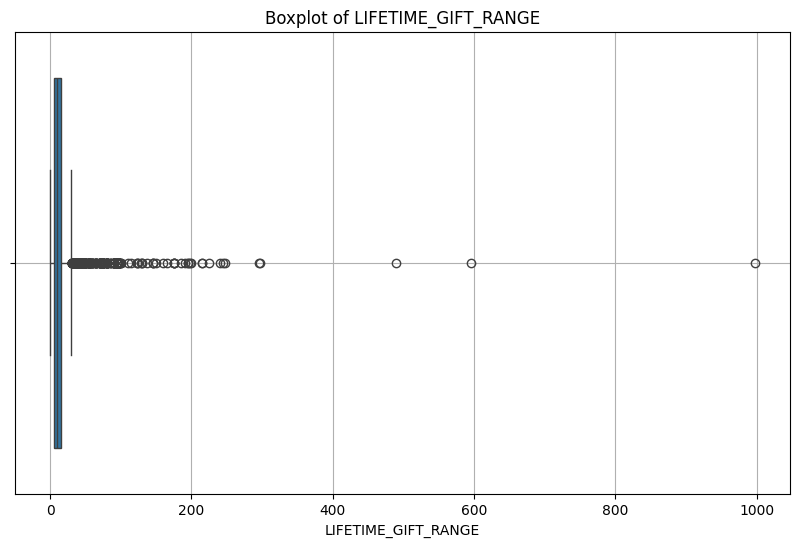

Number of Outliers in LIFETIME_GIFT_RANGE: 673
Summary Statistics for LIFETIME_MAX_GIFT_AMT:
count    19372.000000
mean        19.208808
std         16.101128
min          5.000000
25%         12.000000
50%         16.000000
75%         21.000000
max       1000.000000
Name: LIFETIME_MAX_GIFT_AMT, dtype: float64


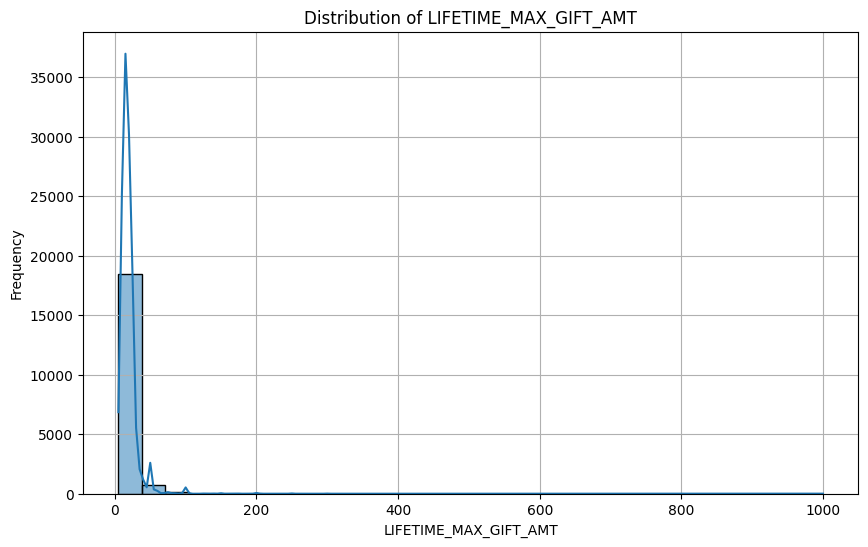

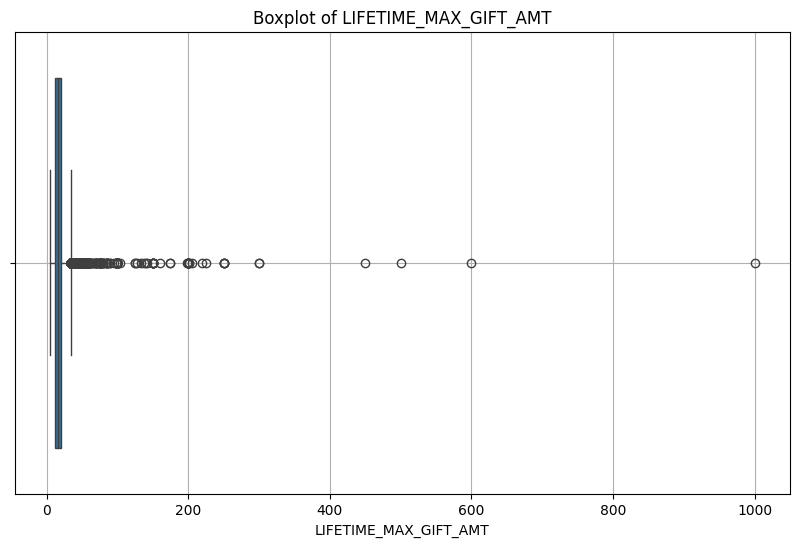

Number of Outliers in LIFETIME_MAX_GIFT_AMT: 1127
Summary Statistics for LIFETIME_MIN_GIFT_AMT:
count    19372.000000
mean         7.620932
std          7.959786
min          0.000000
25%          3.000000
50%          5.000000
75%         10.000000
max        450.000000
Name: LIFETIME_MIN_GIFT_AMT, dtype: float64


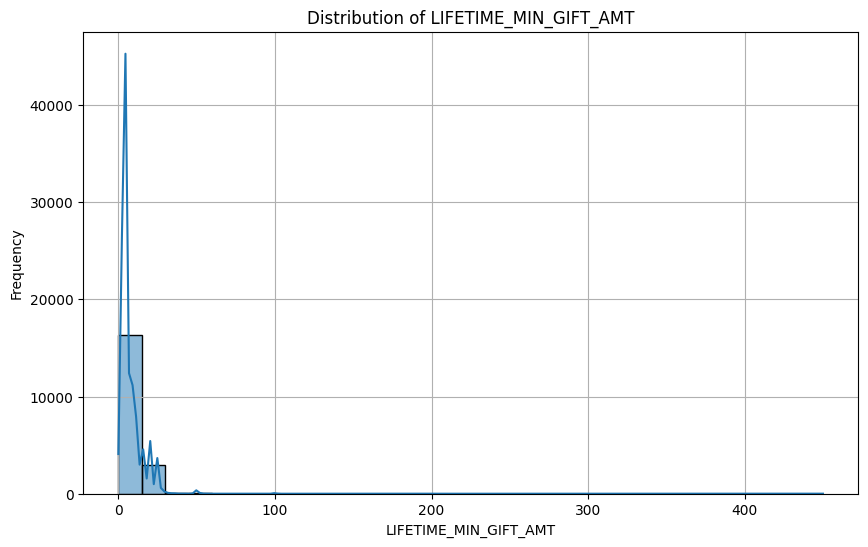

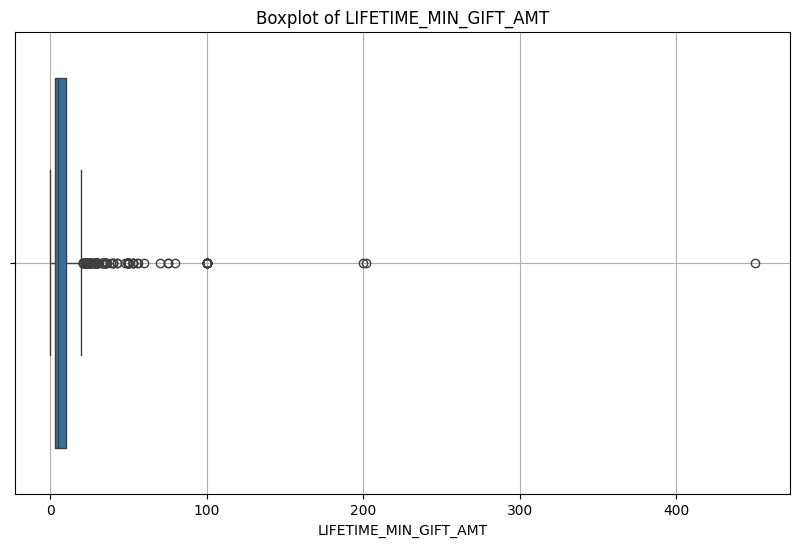

Number of Outliers in LIFETIME_MIN_GIFT_AMT: 895
Summary Statistics for LAST_GIFT_AMT:
count    19372.000000
mean        16.584199
std         11.977558
min          0.000000
25%         10.000000
50%         15.000000
75%         20.000000
max        450.000000
Name: LAST_GIFT_AMT, dtype: float64


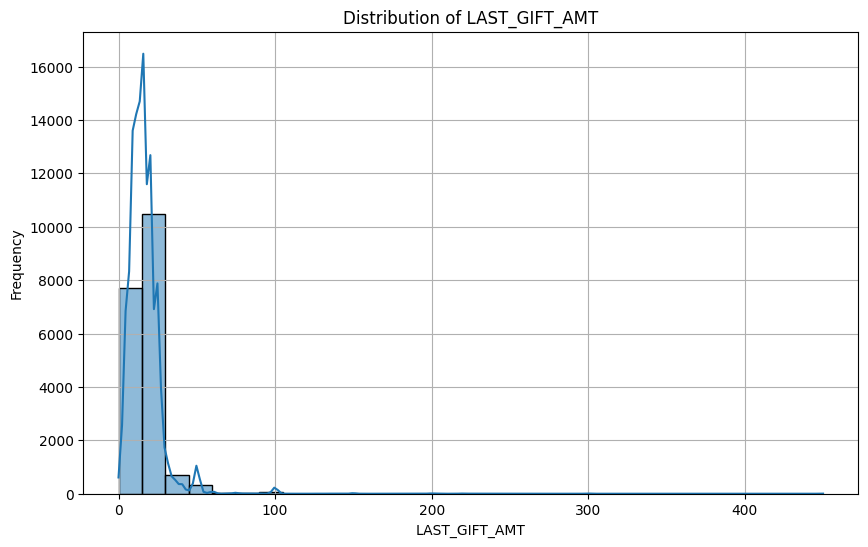

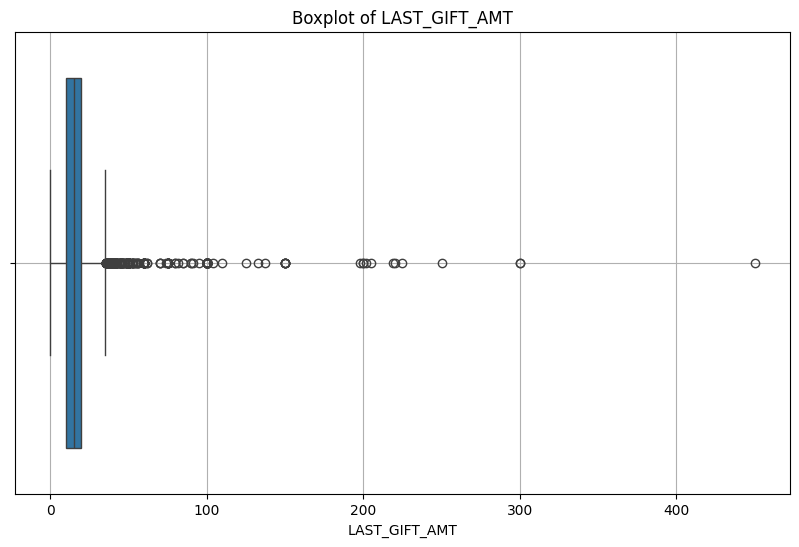

Number of Outliers in LAST_GIFT_AMT: 621
Summary Statistics for CARD_PROM_12:
count    19372.000000
mean         5.367128
std          1.264205
min          0.000000
25%          5.000000
50%          6.000000
75%          6.000000
max         17.000000
Name: CARD_PROM_12, dtype: float64


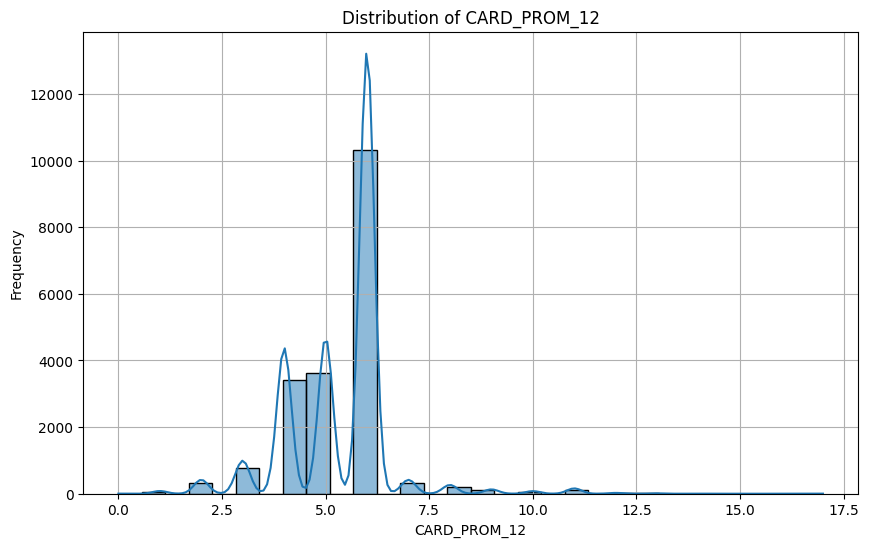

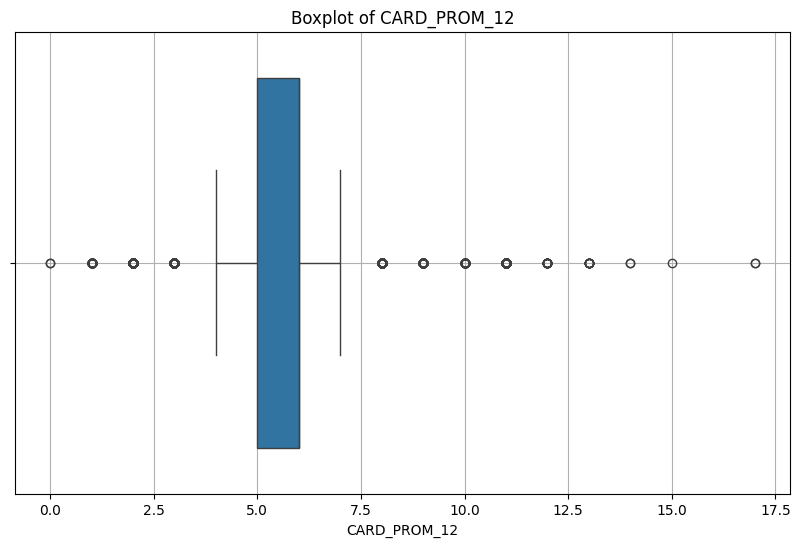

Number of Outliers in CARD_PROM_12: 1684
Summary Statistics for NUMBER_PROM_12:
count    19372.000000
mean        12.901869
std          4.642072
min          2.000000
25%         11.000000
50%         12.000000
75%         13.000000
max         64.000000
Name: NUMBER_PROM_12, dtype: float64


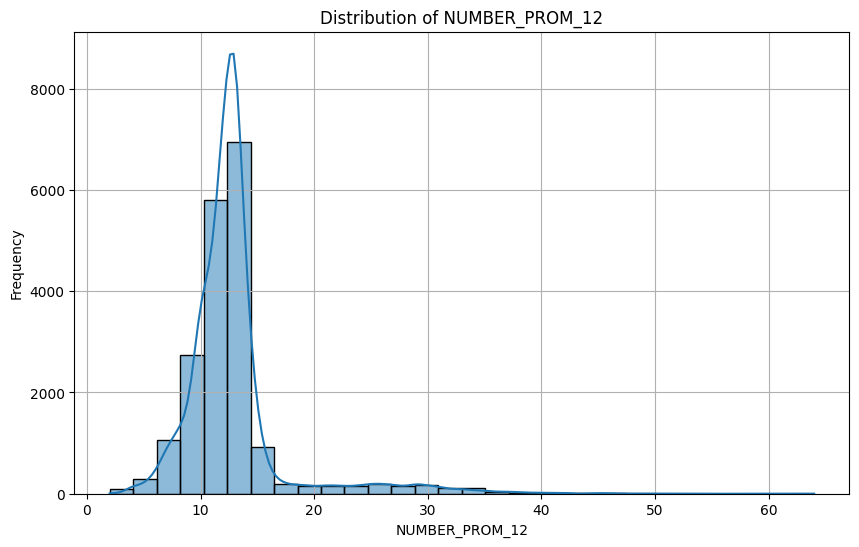

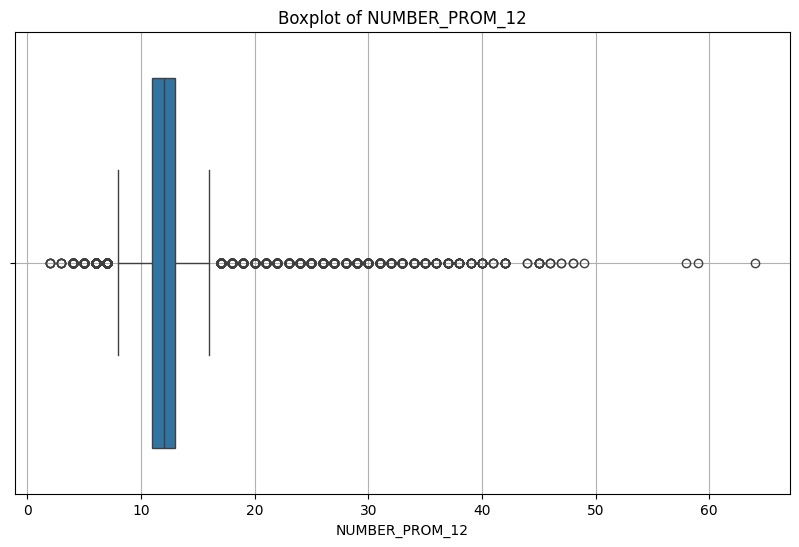

Number of Outliers in NUMBER_PROM_12: 2333
Summary Statistics for MONTHS_SINCE_LAST_GIFT:
count    19372.000000
mean        18.191152
std          4.033065
min          4.000000
25%         16.000000
50%         18.000000
75%         20.000000
max         27.000000
Name: MONTHS_SINCE_LAST_GIFT, dtype: float64


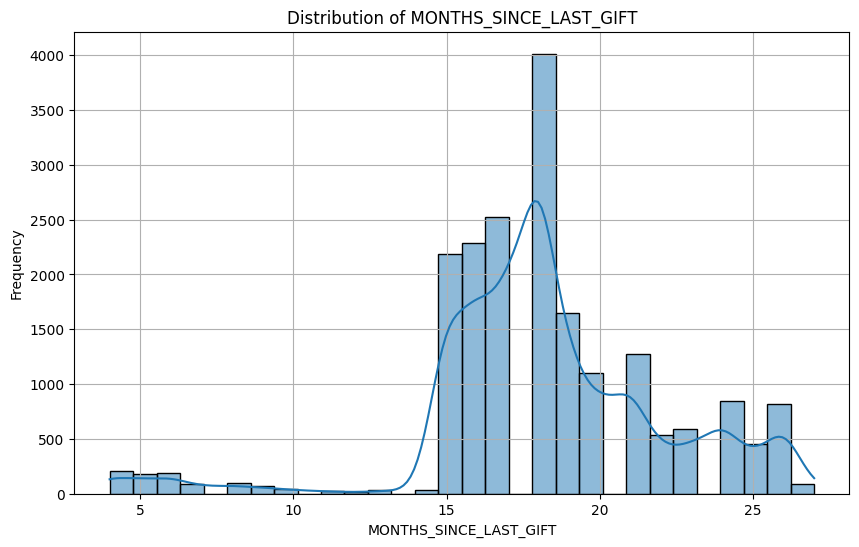

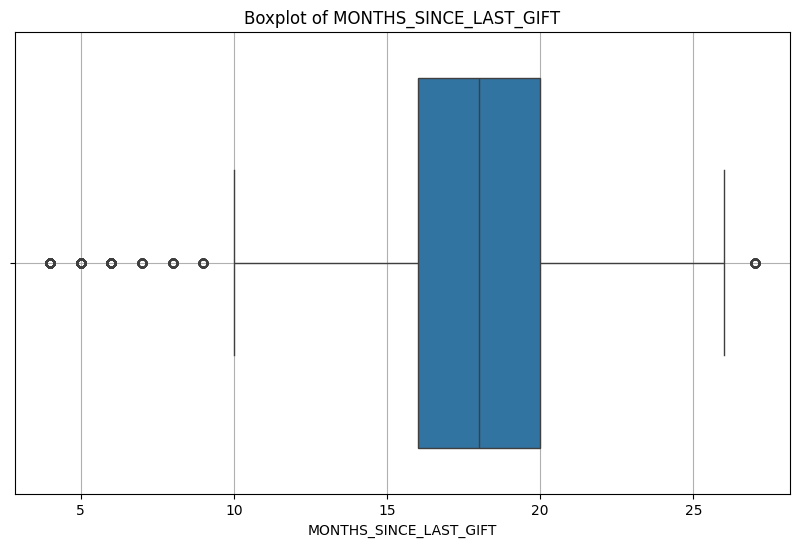

Number of Outliers in MONTHS_SINCE_LAST_GIFT: 927
Summary Statistics for MONTHS_SINCE_FIRST_GIFT:
count    19372.000000
mean        69.482088
std         37.568169
min         15.000000
25%         33.000000
50%         65.000000
75%        105.000000
max        260.000000
Name: MONTHS_SINCE_FIRST_GIFT, dtype: float64


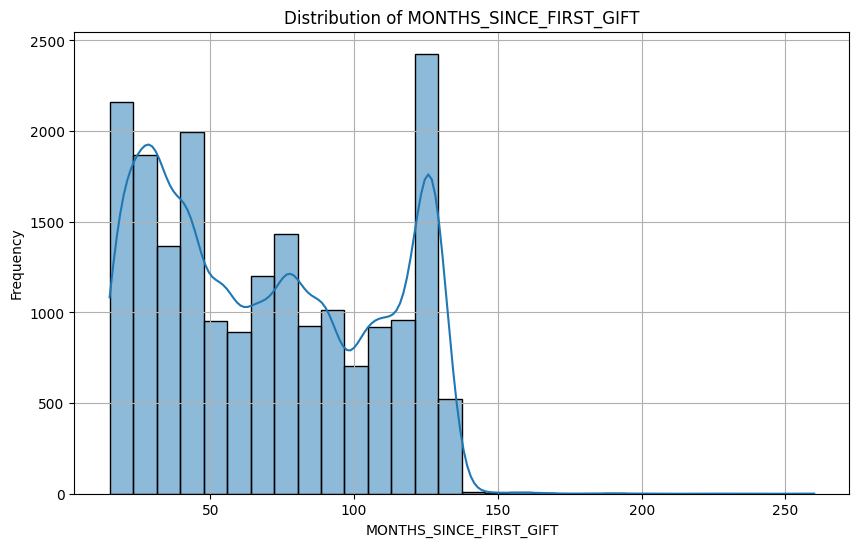

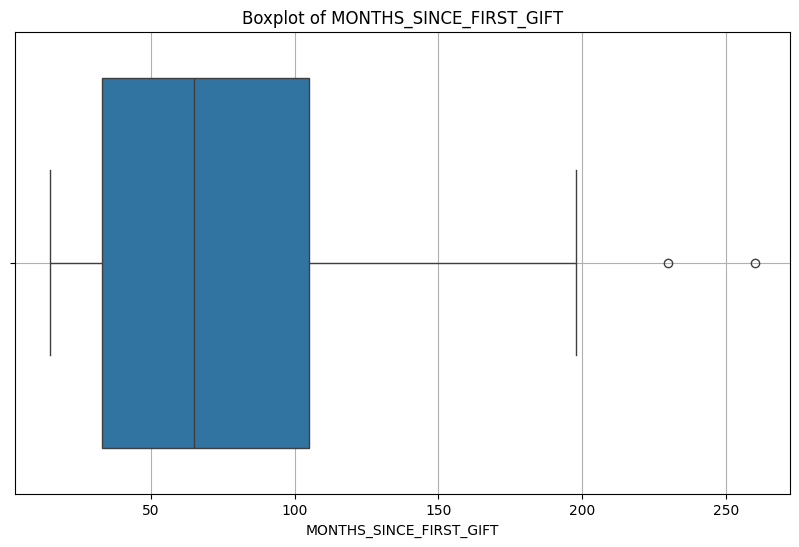

Number of Outliers in MONTHS_SINCE_FIRST_GIFT: 2
Summary Statistics for FILE_AVG_GIFT:
count    19372.000000
mean        12.858338
std          8.787758
min          1.360000
25%          8.000000
50%         11.200000
75%         15.000000
max        450.000000
Name: FILE_AVG_GIFT, dtype: float64


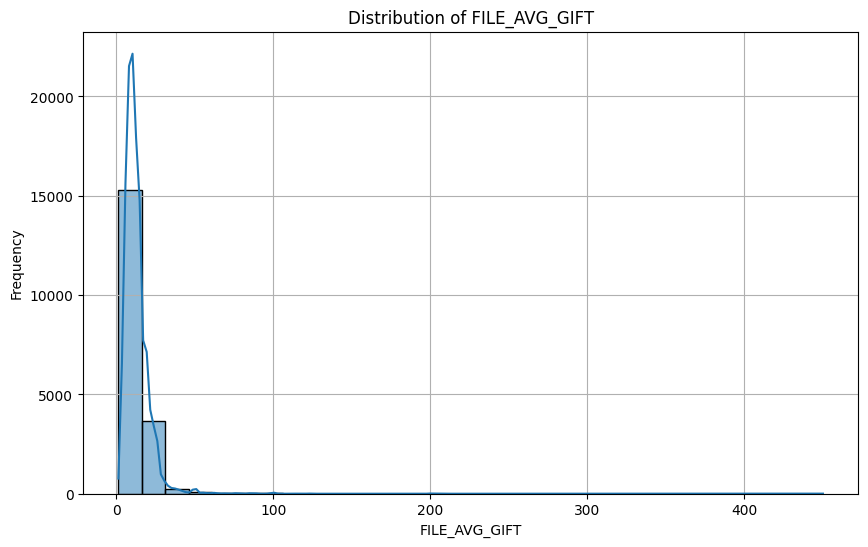

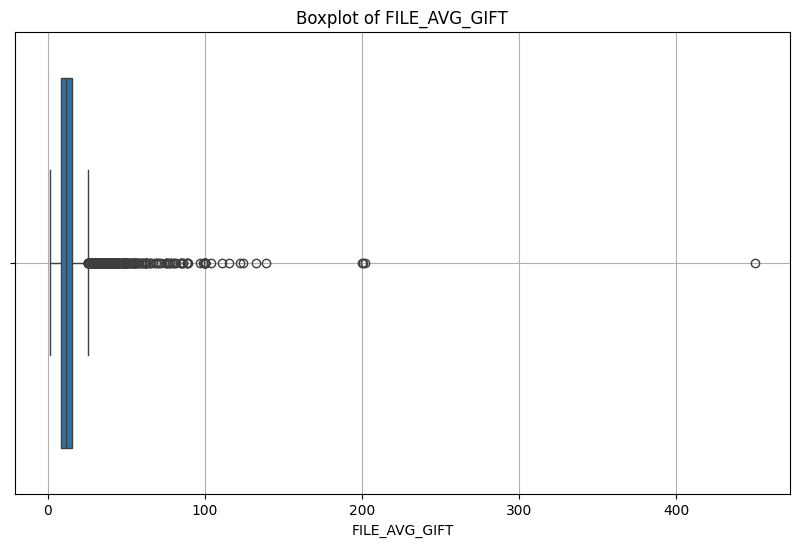

Number of Outliers in FILE_AVG_GIFT: 731
Summary Statistics for FILE_CARD_GIFT:
count    19372.000000
mean         5.273591
std          4.607063
min          0.000000
25%          2.000000
50%          4.000000
75%          8.000000
max         41.000000
Name: FILE_CARD_GIFT, dtype: float64


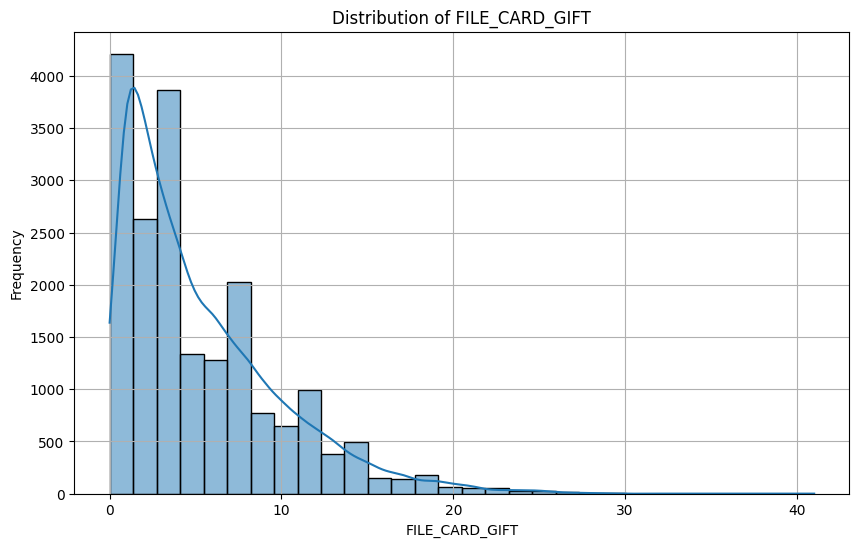

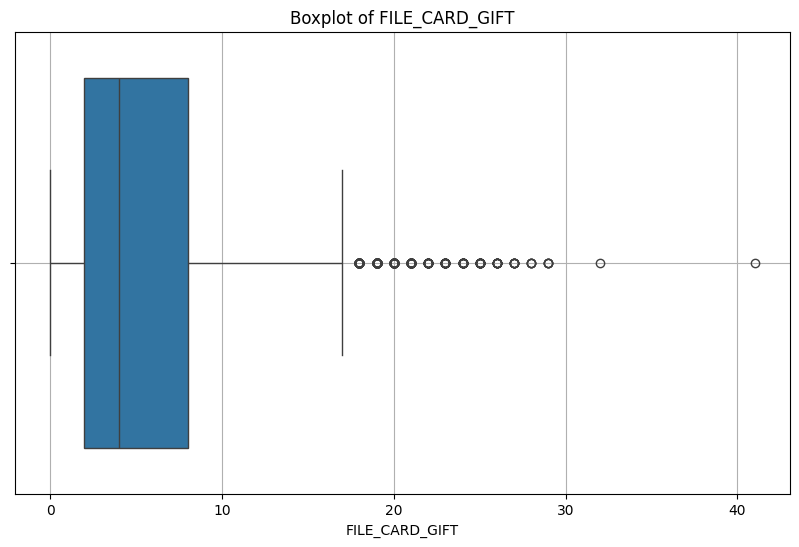

Number of Outliers in FILE_CARD_GIFT: 431


In [20]:
# Define a function to analyze a numerical variable
def analyze_numerical_variable(df, variable):
    # Summary Statistics
    print(f"Summary Statistics for {variable}:")
    print(df[variable].describe())
    
    # Histogram with KDE
    plt.figure(figsize=(10, 6))
    sns.histplot(df[variable], bins=30, kde=True)
    plt.xlabel(variable)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {variable}')
    plt.grid(True)
    plt.show()
    
    # Boxplot
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[variable])
    plt.title(f'Boxplot of {variable}')
    plt.xlabel(variable)
    plt.grid(True)
    plt.show()
    
    # Identify Outliers
    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[variable] < (Q1 - 1.5 * IQR)) | (df[variable] > (Q3 + 1.5 * IQR))]
    print(f"Number of Outliers in {variable}:", outliers.shape[0])
    

# Analyze each variable
numerical_variables = ['TARGET_B',
    'TARGET_D',
    'CONTROL_NUMBER',
    'MONTHS_SINCE_ORIGIN',
    'DONOR_AGE',
    'IN_HOUSE',
    'INCOME_GROUP',
    'PUBLISHED_PHONE',
    'MOR_HIT_RATE',
    'WEALTH_RATING',
    'MEDIAN_HOME_VALUE',
    'MEDIAN_HOUSEHOLD_INCOME',
    'PCT_OWNER_OCCUPIED',
    'PER_CAPITA_INCOME',
    'PCT_ATTRIBUTE1',
    'PCT_ATTRIBUTE2',
    'PCT_ATTRIBUTE3',
    'PCT_ATTRIBUTE4',
    'PEP_STAR',
    'RECENT_STAR_STATUS',
    'FREQUENCY_STATUS_97NK',
    'RECENT_RESPONSE_PROP',
    'RECENT_AVG_GIFT_AMT',
    'RECENT_CARD_RESPONSE_PROP',
    'RECENT_AVG_CARD_GIFT_AMT',
    'RECENT_RESPONSE_COUNT',
    'RECENT_CARD_RESPONSE_COUNT',
    'MONTHS_SINCE_LAST_PROM_RESP',
    'LIFETIME_CARD_PROM',
    'LIFETIME_PROM',
    'LIFETIME_GIFT_AMOUNT',
    'LIFETIME_GIFT_COUNT',
    'LIFETIME_AVG_GIFT_AMT',
    'LIFETIME_GIFT_RANGE',
    'LIFETIME_MAX_GIFT_AMT',
    'LIFETIME_MIN_GIFT_AMT',
    'LAST_GIFT_AMT',
    'CARD_PROM_12',
    'NUMBER_PROM_12',
    'MONTHS_SINCE_LAST_GIFT',
    'MONTHS_SINCE_FIRST_GIFT',
    'FILE_AVG_GIFT',
    'FILE_CARD_GIFT',
]

for var in numerical_variables:
    analyze_numerical_variable(df_donors, var)

In [4]:
# Selecting only numerical variables for correlation analysis
numerical_columns = df_donors.select_dtypes(include=['float64', 'int64']).columns

# Initialize a dictionary to hold the correlation values
correlation_dict = {}

# Calculate Pearson correlation for TARGET_D with each numerical variable
for column in numerical_columns:
    if column != 'TARGET_D' and column != 'TARGET_B':  # Skip the target variable and TARGET_B
        correlation = df_donors['TARGET_D'].corr(df_donors[column])
        correlation_dict[column] = correlation

# Convert the dictionary to a DataFrame for better visualization
correlation_table = pd.DataFrame(correlation_dict.items(), columns=['Variable', 'Pearson Coefficient'])

# Sort the DataFrame by 'Pearson Coefficient' in descending order
correlation_table_sorted = correlation_table.sort_values(by='Pearson Coefficient', ascending=False)

# Display the sorted correlation table
print(correlation_table_sorted.reset_index(drop=True))

                       Variable  Pearson Coefficient
0           RECENT_AVG_GIFT_AMT             0.707250
1                 LAST_GIFT_AMT             0.645388
2                 FILE_AVG_GIFT             0.516724
3         LIFETIME_AVG_GIFT_AMT             0.516724
4      RECENT_AVG_CARD_GIFT_AMT             0.477654
5         LIFETIME_MAX_GIFT_AMT             0.443145
6           LIFETIME_GIFT_RANGE             0.338629
7         LIFETIME_MIN_GIFT_AMT             0.295783
8          LIFETIME_GIFT_AMOUNT             0.247667
9             PER_CAPITA_INCOME             0.135409
10  MONTHS_SINCE_LAST_PROM_RESP             0.133834
11            MEDIAN_HOME_VALUE             0.126180
12                 INCOME_GROUP             0.126074
13      MEDIAN_HOUSEHOLD_INCOME             0.118255
14                WEALTH_RATING             0.114298
15       MONTHS_SINCE_LAST_GIFT             0.090215
16               NUMBER_PROM_12             0.064494
17                     IN_HOUSE             0.

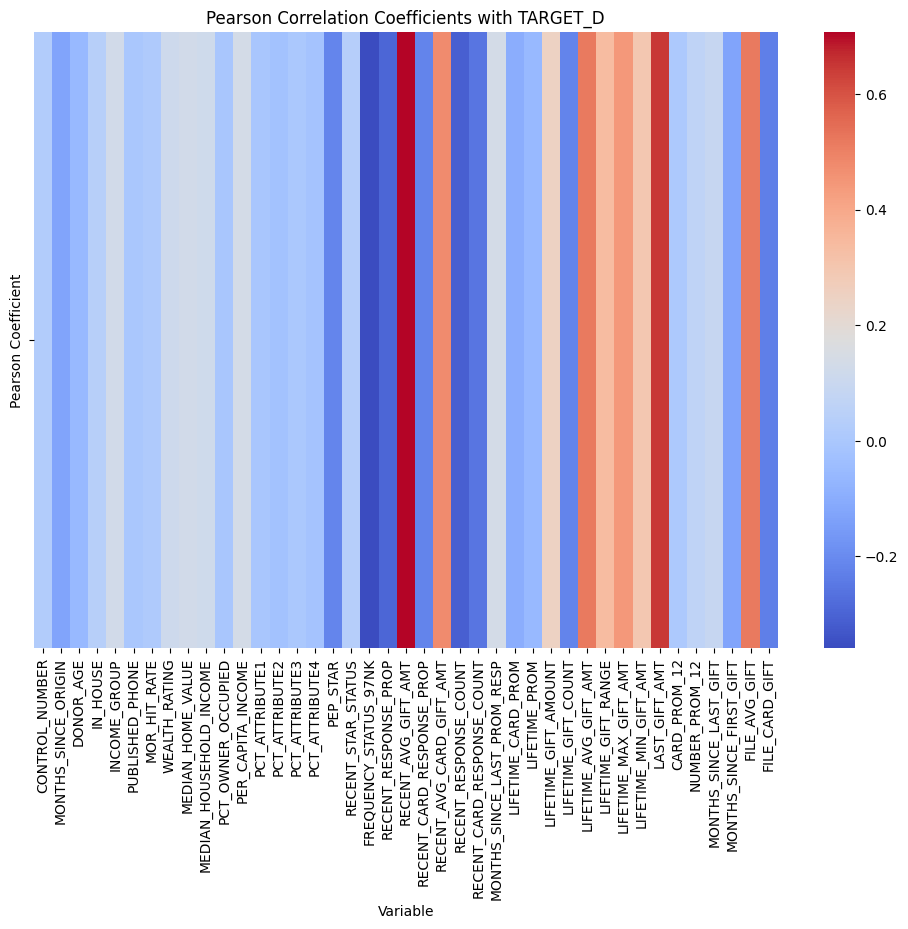

In [ ]:
# Heatmap Visualization of Correlation Coefficients
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_table.set_index('Variable').T, cmap='coolwarm', cbar=True, fmt=".2f")
plt.title('Pearson Correlation Coefficients with TARGET_D')
plt.show()

In [ ]:
# Strongly Positive Correlations (potential features for modeling)
#
#     RECENT_AVG_GIFT_AMT:         0.707250
#     LAST_GIFT_AMT:               0.645388
#     FILE_AVG_GIFT:               0.516724
#     LIFETIME_AVG_GIFT_AMT:       0.516724
#     RECENT_AVG_CARD_GIFT_AMT:    0.477654
#     LIFETIME_MAX_GIFT_AMT:       0.443145
#     LIFETIME_GIFT_RANGE:         0.338629
#     LIFETIME_MIN_GIFT_AMT:       0.295783
#     LIFETIME_GIFT_AMOUNT:        0.247667
#     PER_CAPITA_INCOME:           0.135409
#     MONTHS_SINCE_LAST_PROM_RESP: 0.133834
#     MEDIAN_HOME_VALUE:           0.126180
#     INCOME_GROUP:                 0.126074
#     MEDIAN_HOUSEHOLD_INCOME:      0.118255
#     WEALTH_RATING:                0.114298
#
# Strongly Negative Correlations (potential features for modeling)
#
#     FREQUENCY_STATUS_97NK:         -0.358655
#     RECENT_RESPONSE_COUNT:         -0.312299
#     RECENT_RESPONSE_PROP:          -0.292625
#     RECENT_CARD_RESPONSE_COUNT:    -0.256911
#     FILE_CARD_GIFT:                -0.229592
#     RECENT_CARD_RESPONSE_PROP:     -0.221056
#     LIFETIME_GIFT_COUNT:           -0.220247
#     PEP_STAR:                      -0.215399
#     MONTHS_SINCE_FIRST_GIFT:      -0.127522
#     MONTHS_SINCE_ORIGIN:           -0.126858
#     DONOR_AGE:                    -0.056139
#     LIFETIME_PROM:                -0.057903
#     LIFETIME_CARD_PROM:           -0.097675

In [26]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Supondo que df_donors seja o DataFrame contendo as suas variáveis
# Ajustando o modelo ANOVA
model = ols('TARGET_D ~ C(URBANICITY)', data=df_donors).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Exibindo a tabela ANOVA
print(anova_table)

                      sum_sq      df         F        PR(>F)
C(URBANICITY)    7660.393054     5.0  9.983711  1.612702e-09
Residual       742275.529140  4837.0       NaN           NaN


In [30]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Identifying categorical variables
categorical_columns = df_donors.select_dtypes(include=['object']).columns

# Results for ANOVA
anova_results = {}

for column in categorical_columns:
    if column != 'TARGET_D':  # Ignoring the target variable
        # Fitting the ANOVA model
        model = ols(f'TARGET_D ~ C({column})', data=df_donors).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        # Storing results
        anova_results[column] = anova_table['PR(>F)'].iloc[0]  # P-value

# Converting results to DataFrame for better visualization
anova_results_df = pd.DataFrame(anova_results.items(), columns=['Variable', 'P-Value'])

# Displaying the results
print(anova_results_df)

              Variable       P-Value
0           URBANICITY  1.612702e-09
1                  SES  3.165017e-13
2         CLUSTER_CODE  3.142542e-08
3           HOME_OWNER  5.895921e-01
4         DONOR_GENDER  4.872228e-12
5       OVERLAY_SOURCE  2.945736e-01
6  RECENCY_STATUS_96NK  1.487957e-64


In [ ]:
# Interpretation of Results
#
# The printed DataFrame shows the categorical variables with their respective p-values:
#
#     URBANICITY: 1.612702e-09 — Significant.
#     SES: 3.165017e-13 — Highly significant.
#     CLUSTER_CODE: 3.142542e-08 — Significant.
#     HOME_OWNER: 5.895921e-01 — Not significant.
#     DONOR_GENDER: 4.872228e-12 — Highly significant.
#     OVERLAY_SOURCE: 2.945736e-01 — Not significant.
#     RECENCY_STATUS_96NK: 1.487957e-64 — Highly significant.
#
# Considerations
#
#     P-values < 0.05: Variables with very low p-values (such as URBANICITY, SES,
#     CLUSTER_CODE, DONOR_GENDER, and RECENCY_STATUS_96NK) are statistically significant
#     and may be included in the prediction model.
#     P-values > 0.05: Variables like HOME_OWNER and OVERLAY_SOURCE do not have a
#     significant association with TARGET_D and could be excluded in the context of the model.

In [3]:
import pandas as pd


# Verificar se existem NaNs em TARGET_D quando TARGET_B é igual a 1
nan_in_target_d = df_donors.loc[df_donors['TARGET_B'] == 1, 'TARGET_D'].isna().any()

if nan_in_target_d:
    print("Existem NaNs em TARGET_D mesmo quando TARGET_B = 1.")
else:
    print("Todos os TARGET_B = 1 têm um valor correspondente em TARGET_D.")

Todos os TARGET_B = 1 têm um valor correspondente em TARGET_D.


In [4]:
import pandas as pd

# Verificar se TARGET_D é sempre NaN quando TARGET_B é igual a 0
nan_in_target_d_when_target_b_zero = df_donors.loc[df_donors['TARGET_B'] == 0, 'TARGET_D'].isna().all()

if nan_in_target_d_when_target_b_zero:
    print("TARGET_D é sempre NaN quando TARGET_B = 0.")
else:
    print("Existem valores em TARGET_D quando TARGET_B = 0.")

TARGET_D é sempre NaN quando TARGET_B = 0.


...

## 0.3. Preprocessing Data

Here you might perform data preprocessing that will be used for both supervised and unsupervised learning tasks.

...

## Task 1 (Supervised Learning) - Predicting Donation and Donation Type

In this task you should target 2 classification tasks:
1. **Predicting Donation (binary classification task)** 
2. **Predicting Donation TYPE (multiclass classification)**

**You should:**

* Choose **5 classifiers** from **at least 3 of the following categories**: Tree models, Probabilistic models, Distance-based models and Linear models. You can also try one Ensemble Classifier (https://scikit-learn.org/1.5/modules/ensemble.html). 
* Use **cross-validation** to evaluate the results.
* Describe the parameters used for each classifier and how their choice impacted or not the results.
* Choose the **best classifier** and fundament you choice.
* Present and discuss the results for different evaluation measures, present confusion matrices. Remember that not only overall results are important. Check what happens when learning to predict each class. Remember also that some metrics might be more adequate than others according to the problem at hand.

* **Discuss critically your choices and the results!**

## 1.1. Specific Data Preprocessing for Classification

In [ ]:
### Data preprocessing

# Load the data
data = pd.read_csv('Donors_dataset.csv')

# Select features and target variable
num_features = [
    'RECENT_AVG_GIFT_AMT',
    'LAST_GIFT_AMT',
    'LIFETIME_AVG_GIFT_AMT',
    'RECENT_AVG_CARD_GIFT_AMT',
    'LIFETIME_MAX_GIFT_AMT'
]

cat_features = [
    'URBANICITY',
    'SES',
    'CLUSTER_CODE',
    'DONOR_GENDER',
    'RECENCY_STATUS_96NK'
]

# Keeping only TARGET_B + selected predictors
df_B = df_donors[['TARGET_B'] + num_features + cat_features].copy() #copies the chosen features to df_B

# check missing values in these columns
print(df_B.isna().sum()) # df_B.isna() creates a dataframe with True and False, in terms of having a value. Then all the trues are summed as ones.

# One-hot encode categorical variables. Creates Dummy tables for the categorical features.
df_B_encoded = pd.get_dummies(df_B, columns=cat_features, drop_first=True) #  The drop_first, condenses the results by making one of the features the reference. supposidly it does not affect the results.

# Final X and y for TARGET_B model
X_B = df_B_encoded.drop('TARGET_B', axis=1)
y_B = df_B_encoded['TARGET_B']

X_B.head()

TARGET_B                    0
RECENT_AVG_GIFT_AMT         0
LAST_GIFT_AMT               0
LIFETIME_AVG_GIFT_AMT       0
RECENT_AVG_CARD_GIFT_AMT    0
LIFETIME_MAX_GIFT_AMT       0
URBANICITY                  0
SES                         0
CLUSTER_CODE                0
DONOR_GENDER                0
RECENCY_STATUS_96NK         0
dtype: int64


,RECENT_AVG_GIFT_AMT,LAST_GIFT_AMT,LIFETIME_AVG_GIFT_AMT,RECENT_AVG_CARD_GIFT_AMT,LIFETIME_MAX_GIFT_AMT,URBANICITY_C,URBANICITY_R,URBANICITY_S,URBANICITY_T,URBANICITY_U,...,CLUSTER_CODE_8,CLUSTER_CODE_9,DONOR_GENDER_F,DONOR_GENDER_M,DONOR_GENDER_U,RECENCY_STATUS_96NK_E,RECENCY_STATUS_96NK_F,RECENCY_STATUS_96NK_L,RECENCY_STATUS_96NK_N,RECENCY_STATUS_96NK_S
0,15.00,15.0,8.49,0.00,20.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,15.00,17.0,14.72,15.00,25.0,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,21.67,19.0,16.75,22.67,28.0,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,True
3,13.44,15.0,11.76,13.50,17.0,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
4,17.50,25.0,8.83,10.00,25.0,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False


## 1.2. Learning and Evaluating Classifiers

...

TARGET_B                    0
RECENT_AVG_GIFT_AMT         0
LAST_GIFT_AMT               0
LIFETIME_AVG_GIFT_AMT       0
RECENT_AVG_CARD_GIFT_AMT    0
LIFETIME_MAX_GIFT_AMT       0
URBANICITY                  0
SES                         0
CLUSTER_CODE                0
DONOR_GENDER                0
RECENCY_STATUS_96NK         0
dtype: int64
Fitting 5 folds for each of 90 candidates, totalling 450 fits
Melhores hiperparâmetros: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


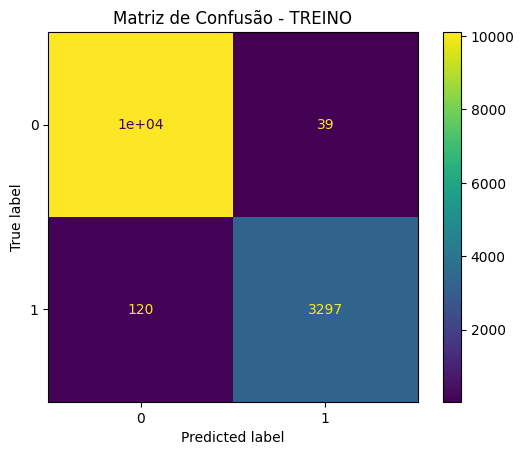

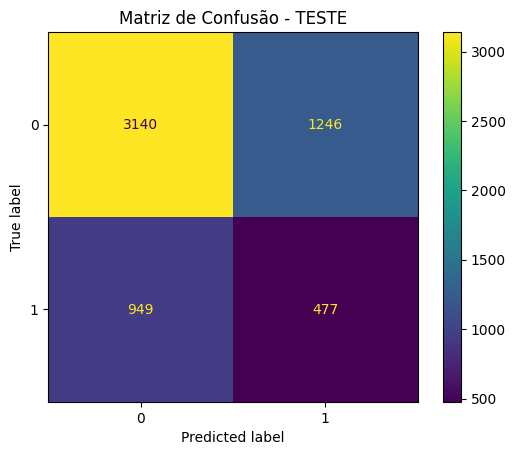


CLASSIFICAÇÃO - TREINO:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     10143
           1       0.99      0.96      0.98      3417

    accuracy                           0.99     13560
   macro avg       0.99      0.98      0.98     13560
weighted avg       0.99      0.99      0.99     13560

CLASSIFICAÇÃO - TESTE:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74      4386
           1       0.28      0.33      0.30      1426

    accuracy                           0.62      5812
   macro avg       0.52      0.53      0.52      5812
weighted avg       0.65      0.62      0.63      5812



In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import ADASYN
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('Donors_dataset.csv')

# Select features and target variable
num_features = [
    'RECENT_AVG_GIFT_AMT', 
    'LAST_GIFT_AMT', 
    'LIFETIME_AVG_GIFT_AMT', 
    'RECENT_AVG_CARD_GIFT_AMT',
    'LIFETIME_MAX_GIFT_AMT'
]

cat_features = [
    'URBANICITY', 
    'SES', 
    'CLUSTER_CODE', 
    'DONOR_GENDER', 
    'RECENCY_STATUS_96NK'
]

# Keeping only TARGET_B and selected predictors
df_B = data[['TARGET_B'] + num_features + cat_features].copy()

# Check for missing values in these columns
print(df_B.isna().sum())

# Final X and y for the model
X = df_B.drop('TARGET_B', axis=1)
y = df_B['TARGET_B']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Apply One-Hot Encoding for categorical variables
X_train = pd.get_dummies(X_train, columns=cat_features, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_features, drop_first=True)

# Ensure both train and test sets have the same columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Apply ADASYN for handling class imbalance
adasyn = ADASYN(random_state=42)
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)

# Define the model
model = DecisionTreeClassifier(random_state=42)

# Define the parameters to be tuned
param_grid = {
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, 
                           scoring='f1', cv=5, verbose=1, n_jobs=-1)

# Fit the hyperparameters
grid_search.fit(X_train_resampled, y_train_resampled)

# Best hyperparameters
best_params = grid_search.best_params_
print("Melhores hiperparâmetros:", best_params)

# Evaluate the model with the best hyperparameters
best_model = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train)  # Predictions on the training set
y_test_pred = best_model.predict(X_test)     # Predictions on the test set

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=best_model.classes_)
disp_train.plot()
plt.title("Matriz de Confusão - TREINO")
plt.show()

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=best_model.classes_)
disp_test.plot()
plt.title("Matriz de Confusão - TESTE")
plt.show()

# Evaluation metrics
from sklearn.metrics import f1_score

# F1 Score for class 1 (donors)
f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

print("\nCLASSIFICAÇÃO - TREINO:")
print(classification_report(y_train, y_train_pred))

print("CLASSIFICAÇÃO - TESTE:")
print(classification_report(y_test, y_test_pred))

In [ ]:
"""

- **Precision for Class 0 (non-donors)**: 0.77, indicating that 77% of predicted non-donors were correct.
- **Recall for Class 0**: 0.72, meaning 72% of actual non-donors were identified correctly.
- **Precision for Class 1 (donors)**: 0.28, showing a low effectiveness in identifying actual donors.
- **Recall for Class 1**: 0.33, indicating that only 33% of actual donors were correctly predicted.
- **Overall Accuracy**: 63%, which suggests there's room for improvement, particularly in how donors are classified.

### Recommendations for Improvement

1. **Address Class Imbalance**: The dataset appears to be imbalanced, with many more non-donors than donors. 
Techniques such as **oversampling the minority class**, **undersampling the majority class**, 
or employing **SMOTE (Synthetic Minority Over-sampling Technique)** can help to balance the dataset.

2. **Hyperparameter Tuning**: Experiment with different parameters of the **DecisionTreeClassifier**, such as:
- `max_depth` to control tree depth
- `min_samples_split` to require a minimum number of samples in a node before splitting
- `min_samples_leaf` to control the minimum number of samples for a leaf node

3. **Tree Pruning**: To avoid overfitting, you might want to look into **pruning** the decision tree, which can enhance its generalization capabilities.

4. **Feature Engineering**: Explore additional features or engineering new ones that might improve model performance. Understanding feature importances can guide this process.

5. **Try Alternative Models**: Decision trees can perform well, but you may want to experiment with ensemble methods
 like **Random Forest** or **Gradient Boosting** that typically yield better performance on classification tasks.

6. **Cross-Validation**: Implement **k-fold cross-validation** to assess the model's performance more robustly and ensure that the results are consistent.

### Next Steps

Implementing these strategies could significantly enhance the model's predictive power, especially for the underrepresented class of donors. 
Would you like assistance with any specific technique or further analysis?
"""


In [ ]:
"""
Recommendations

    **Class Imbalance Handling**:
        Further techniques like SMOTE (Synthetic Minority Over-sampling Technique) or adjusting class weights in the model might help improve the model's ability to capture class 1.

    Model Complexity Control:
        Consider setting a limit on max_depth to avoid overfitting and improve generalization.

    Feature Importance Evaluation:
        Analyze which features contribute most to predictions and refine the feature set accordingly.

    Explore Other Models:
        Test different algorithms that handle class imbalance better, such as Random Forests or Gradient Boosting models.

"""

## 1.3. Classification - Final Discussion and Conclusions 

...

## Task 2 (Unsupervised Learning) - Characterizing Donors and Donation Type

In this task you should **use unsupervised learning to characterize donors (people who really did a donation) and their donation type**.
1. **Use clustering algorithms to find similar groups of donors**. Is it possible to find groups of donors with the same/similar DonationTYPE? Evaluate clustering results using **internal and external metrics**.
2. **Be creative and define and explore your own clustering task!** What else would it be interesting to find out?

## 2.1. Preprocessing Data for Clustering

...

## 2.2. Learning and Evaluating Clusterings

...

## 2.3. Clustering - Final Discussion and Conclusions

...

## 3. Final Comments and Conclusions

...